# final working

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
df=pd.read_csv("data/sortedWithepsPeNIC.csv")

In [3]:
df.head(1)

,Date,Open,High,Low,Close,Qty,Turnover,EPS,PE
0,10/17/2016,660.0,660.0,647.0,651.0,5758,3758521.0,17.94,36.287625


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1919 non-null   object 
 1   Open      1919 non-null   float64
 2   High      1919 non-null   float64
 3   Low       1919 non-null   float64
 4   Close     1919 non-null   float64
 5   Qty       1919 non-null   int64  
 6   Turnover  1919 non-null   float64
 7   EPS       1919 non-null   float64
 8   PE        1919 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 135.1+ KB


In [5]:
df.drop("Turnover", axis=1, inplace=True)

df['Date'] = pd.to_datetime(df['Date']) 

df.set_index('Date', inplace=True)
# df = df.apply(lambda x: x.astype(str).str.replace(',', '', regex=True))

df['pchange'] = df['Close'].pct_change()*100
df.isnull().sum()

Open       0
High       0
Low        0
Close      0
Qty        0
EPS        0
PE         0
pchange    1
dtype: int64

In [6]:
#removing null values by bfill:
df.bfill(inplace=True)

# df.sort_values(by=["Date"], inplace=True, ascending=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1919 entries, 2016-10-17 to 2025-02-20
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Open     1919 non-null   float64
 1   High     1919 non-null   float64
 2   Low      1919 non-null   float64
 3   Close    1919 non-null   float64
 4   Qty      1919 non-null   int64  
 5   EPS      1919 non-null   float64
 6   PE       1919 non-null   float64
 7   pchange  1919 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 134.9 KB


In [8]:
#calculating EMA:
import talib as ta
df['EMA5'] = ta.EMA(df['Close'], timeperiod=5)
df['EMA50'] = ta.EMA(df['Close'], timeperiod=50)
df['EMA200'] = ta.EMA(df['Close'], timeperiod=200)

In [9]:
#calculating RSI:
df['RSI9'] = ta.RSI(df['Close'], timeperiod=9)
df['RSI14'] = ta.RSI(df['Close'], timeperiod=14)
df['RSI25'] = ta.RSI(df['Close'], timeperiod=25)


In [10]:
df['MACD'], df['MACDSignal'], df['MACDHist'] = ta.MACD(df['Close'], 
                                                             fastperiod=12, 
                                                             slowperiod=26, 
                                                             signalperiod=9)

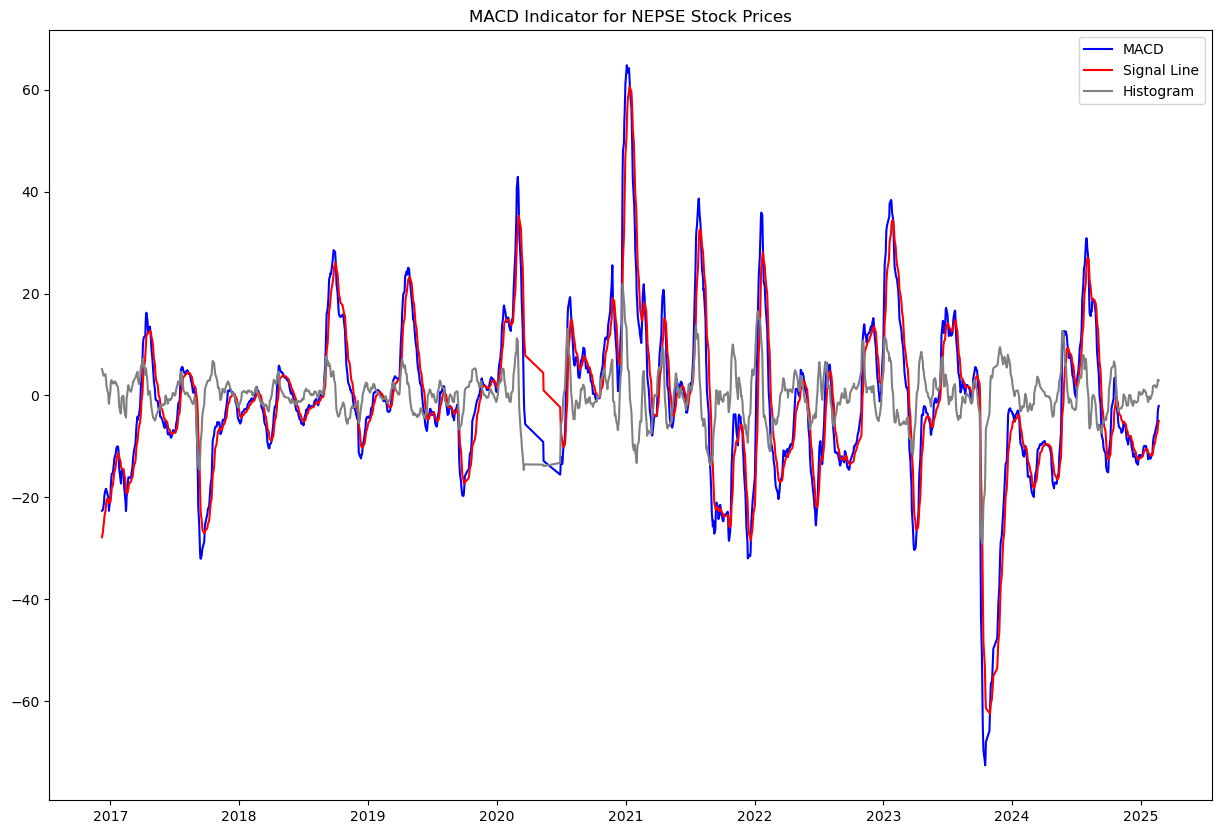

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plt.plot(df['MACD'], label="MACD", color='blue')
plt.plot(df['MACDSignal'], label="Signal Line", color='red')
plt.plot(df.index, df['MACDHist'], label="Histogram", color='gray')
plt.legend()
plt.title("MACD Indicator for NEPSE Stock Prices")
plt.show()


In [12]:
df['BollingerUpper'], df['BollingerMiddle'], df['BollingerLower'] = ta.BBANDS(df['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)


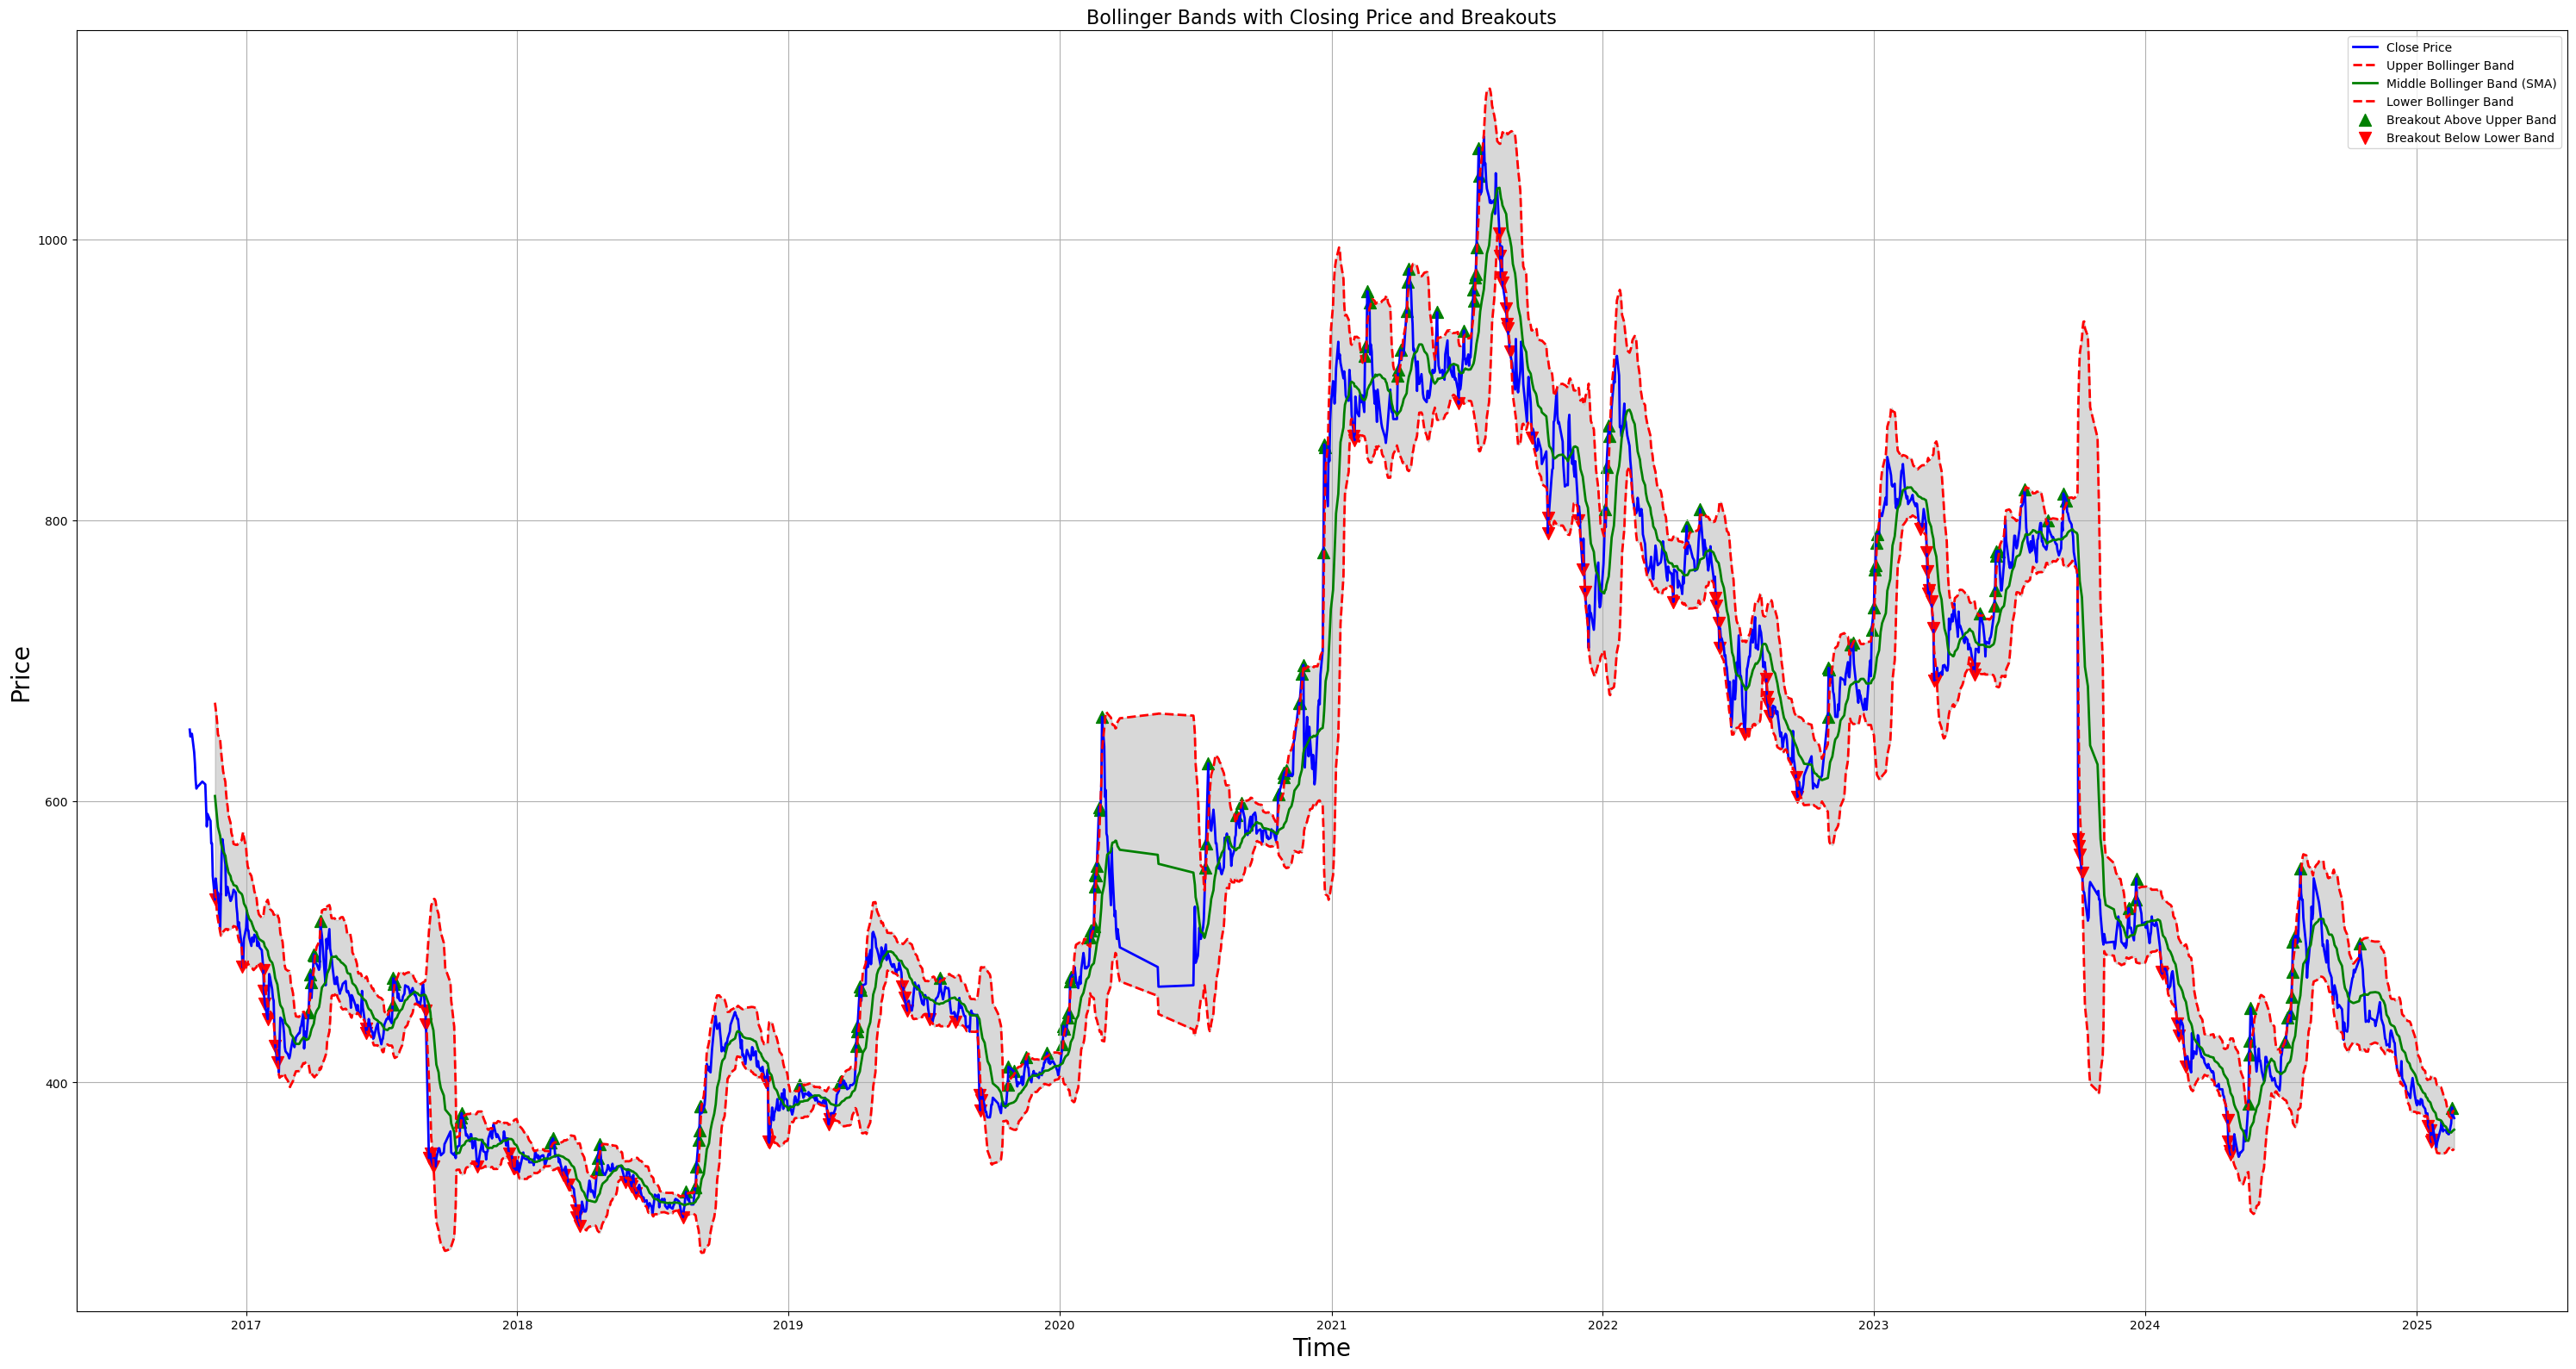

In [13]:
# Plotting the Closing Price and Bollinger Bands
plt.figure(figsize=(30,16))

# Plotting the Close Price
plt.plot(df['Close'], label='Close Price', color='blue', lw=2)

# Plotting the Bollinger Bands
plt.plot(df['BollingerUpper'], label='Upper Bollinger Band', color='red', linestyle='--', lw=2)
plt.plot(df['BollingerMiddle'], label='Middle Bollinger Band (SMA)', color='green', lw=2)
plt.plot(df['BollingerLower'], label='Lower Bollinger Band', color='red', linestyle='--', lw=2)

# Filling the area between Upper and Lower Bands for volatility
plt.fill_between(df.index, df['BollingerLower'], df['BollingerUpper'], color='gray', alpha=0.3)

# Highlight when price crosses above the Upper Band or below the Lower Band
plt.scatter(df.index[df['Close'] > df['BollingerUpper']], 
            df['Close'][df['Close'] > df['BollingerUpper']], 
            color='green', marker='^', label='Breakout Above Upper Band', s=100)

plt.scatter(df.index[df['Close'] < df['BollingerLower']], 
            df['Close'][df['Close'] < df['BollingerLower']], 
            color='red', marker='v', label='Breakout Below Lower Band', s=100)

# Title, labels, and legend
plt.title('Bollinger Bands with Closing Price and Breakouts', fontsize=16)
plt.xlabel('Time', fontsize=20)
plt.ylabel('Price', fontsize=20)
plt.legend(loc='best')

# Add gridlines for better clarity
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [14]:
# Calculate the ATR (Average True Range) for a 14-period window
df['ATR'] = ta.ATR(df['High'], df['Low'], df['Close'], timeperiod=10)

# Supertrend calculation parameters
multiplier = 3
df['UpperBand'] = (df['High'] + df['Low']) / 2 + (multiplier * df['ATR'])
df['LowerBand'] = (df['High'] + df['Low']) / 2 - (multiplier * df['ATR'])

# Initialize Supertrend column
df['Supertrend'] = 0.0

# Set initial values for Supertrend
upper_band = df['UpperBand'].values
lower_band = df['LowerBand'].values
close = df['Close'].values
supertrend = df['Supertrend'].values

for i in range(1, len(df)):
    if close[i] > upper_band[i-1]:
        supertrend[i] = lower_band[i]
    elif close[i] < lower_band[i-1]:
        supertrend[i] = upper_band[i]
    else:
        supertrend[i] = supertrend[i-1]

df['Supertrend'] = supertrend


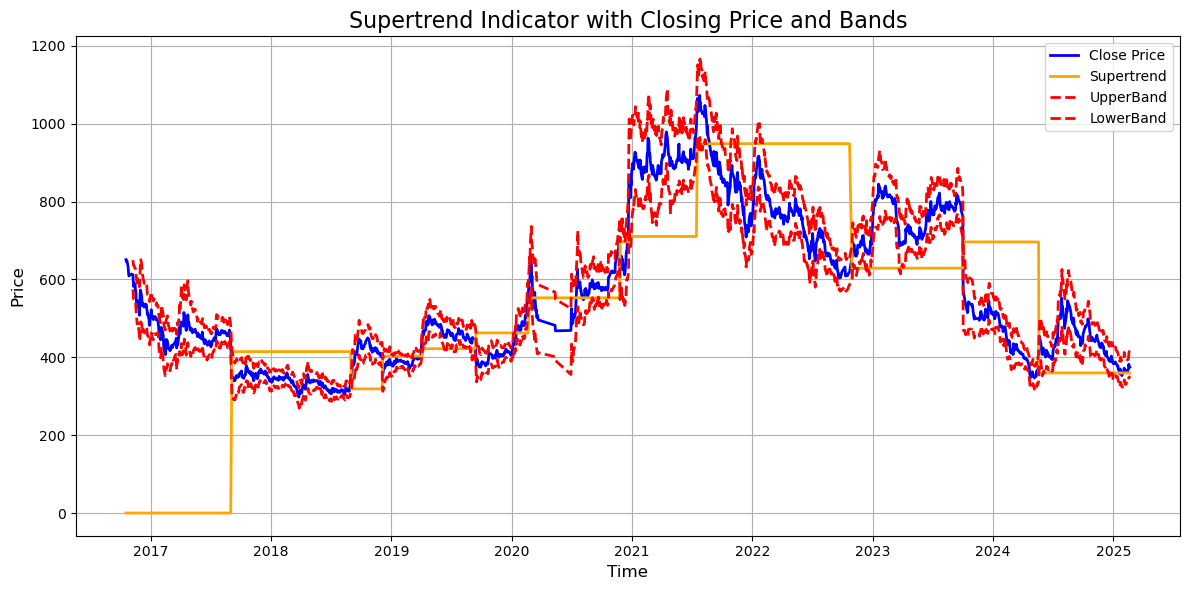

In [15]:
# Plotting the Supertrend with Closing Price
plt.figure(figsize=(12,6))

# Plotting the Close Price
plt.plot(df['Close'], label='Close Price', color='blue', lw=2)

# Plotting the Supertrend
plt.plot(df['Supertrend'], label='Supertrend', color='orange', lw=2)

# Plotting the Upper and Lower Bands for reference
plt.plot(df['UpperBand'], label='UpperBand', color='red', linestyle='--', lw=2)
plt.plot(df['LowerBand'], label='LowerBand', color='red', linestyle='--', lw=2)

# Title, labels, and legend
plt.title('Supertrend Indicator with Closing Price and Bands', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(loc='best')

# Add gridlines for better clarity
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

C:\Users\anshg\AppData\Local\Temp\ipykernel_18684\579696729.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if df['Close'][i] > df['Supertrend'][i] and df['Close'][i-1] < df['Supertrend'][i-1]:
C:\Users\anshg\AppData\Local\Temp\ipykernel_18684\579696729.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif df['Close'][i] < df['Supertrend'][i] and df['Close'][i-1] > df['Supertrend'][i-1]:
C:\Users\anshg\AppData\Local\Temp\ipykernel_18684\579696729.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent wi

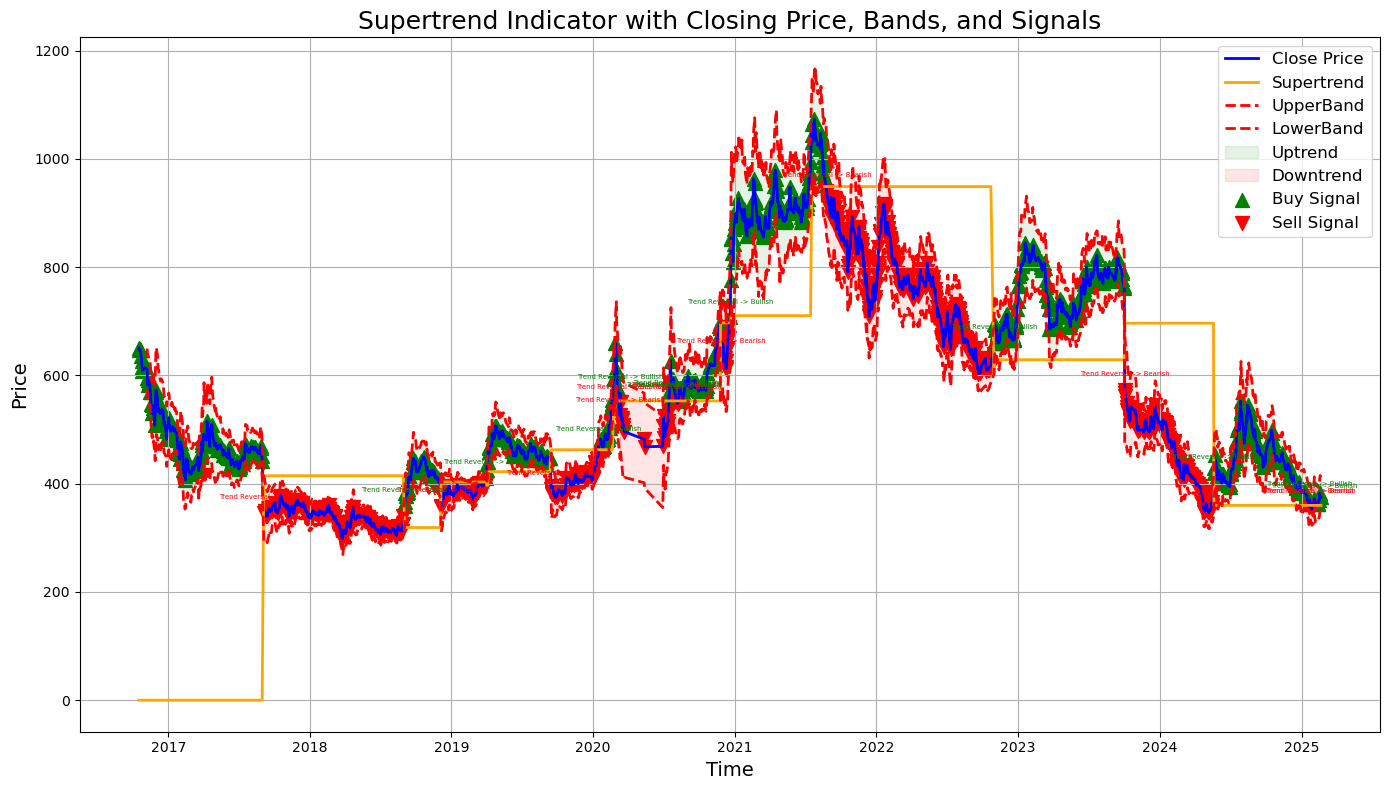

In [16]:


# Plotting the Supertrend with Closing Price
plt.figure(figsize=(14, 8))

# Plotting the Close Price
plt.plot(df['Close'], label='Close Price', color='blue', lw=2)

# Plotting the Supertrend
plt.plot(df['Supertrend'], label='Supertrend', color='orange', lw=2)

# Plotting the Upper and Lower Bands for reference
plt.plot(df['UpperBand'], label='UpperBand', color='red', linestyle='--', lw=2)
plt.plot(df['LowerBand'], label='LowerBand', color='red', linestyle='--', lw=2)

# Shading the areas for Uptrend and Downtrend
plt.fill_between(df.index, df['LowerBand'], df['UpperBand'], where=(df['Close'] > df['Supertrend']), color='green', alpha=0.1, label='Uptrend')
plt.fill_between(df.index, df['LowerBand'], df['UpperBand'], where=(df['Close'] < df['Supertrend']), color='red', alpha=0.1, label='Downtrend')

# Highlight Buy and Sell signals (where price crosses the Supertrend)
buy_signals = df[df['Close'] > df['Supertrend']].index
sell_signals = df[df['Close'] < df['Supertrend']].index

plt.scatter(buy_signals, df['Close'][buy_signals], color='green', marker='^', label='Buy Signal', s=100)
plt.scatter(sell_signals, df['Close'][sell_signals], color='red', marker='v', label='Sell Signal', s=100)

# Title, labels, and legend
plt.title('Supertrend Indicator with Closing Price, Bands, and Signals', fontsize=18)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.legend(loc='best', fontsize=12)

# Add gridlines for better clarity
plt.grid(True)

# Annotate for clarity (if needed)
for i in range(1, len(df)):
    if df['Close'][i] > df['Supertrend'][i] and df['Close'][i-1] < df['Supertrend'][i-1]:
        plt.annotate('Trend Reversal -> Bullish', (df.index[i], df['Close'][i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=5, color='green')
    elif df['Close'][i] < df['Supertrend'][i] and df['Close'][i-1] > df['Supertrend'][i-1]:
        plt.annotate('Trend Reversal -> Bearish', (df.index[i], df['Close'][i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=5, color='red')

# Show the plot
plt.tight_layout()
plt.show()


In [17]:
# df.drop(columns=["EMA5", "EMA50", "EMA200","UpperBand","LowerBand","Supertrend"], inplace=True)


# df.head()

In [18]:
df = df.bfill()

In [19]:
df.head()

,Open,High,Low,Close,Qty,EPS,PE,pchange,EMA5,EMA50,...,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR,UpperBand,LowerBand,Supertrend
Date,,,,,,,,,,,,,,,,,,,,,
2016-10-17,660.0,660.0,647.0,651.0,5758,17.94,36.287625,-0.768049,645.6,558.32,...,-22.644189,-27.826677,5.182488,670.102108,603.7,537.297892,12.5,649.5,574.5,0.0
2016-10-18,651.0,655.0,644.0,646.0,6085,17.94,36.008919,-0.768049,645.6,558.32,...,-22.644189,-27.826677,5.182488,670.102108,603.7,537.297892,12.5,649.5,574.5,0.0
2016-10-19,646.0,651.0,642.0,648.0,6977,17.94,36.120401,0.309598,645.6,558.32,...,-22.644189,-27.826677,5.182488,670.102108,603.7,537.297892,12.5,649.5,574.5,0.0
2016-10-20,648.0,651.0,643.0,648.0,3303,17.94,36.120401,0.000000,645.6,558.32,...,-22.644189,-27.826677,5.182488,670.102108,603.7,537.297892,12.5,649.5,574.5,0.0
2016-10-23,648.0,650.0,633.0,635.0,6063,17.94,35.395764,-2.006173,645.6,558.32,...,-22.644189,-27.826677,5.182488,670.102108,603.7,537.297892,12.5,649.5,574.5,0.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1919 entries, 2016-10-17 to 2025-02-20
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Open             1919 non-null   float64
 1   High             1919 non-null   float64
 2   Low              1919 non-null   float64
 3   Close            1919 non-null   float64
 4   Qty              1919 non-null   int64  
 5   EPS              1919 non-null   float64
 6   PE               1919 non-null   float64
 7   pchange          1919 non-null   float64
 8   EMA5             1919 non-null   float64
 9   EMA50            1919 non-null   float64
 10  EMA200           1919 non-null   float64
 11  RSI9             1919 non-null   float64
 12  RSI14            1919 non-null   float64
 13  RSI25            1919 non-null   float64
 14  MACD             1919 non-null   float64
 15  MACDSignal       1919 non-null   float64
 16  MACDHist         1919 non-null   float64
 

In [21]:
df.isna().sum()

Open               0
High               0
Low                0
Close              0
Qty                0
EPS                0
PE                 0
pchange            0
EMA5               0
EMA50              0
EMA200             0
RSI9               0
RSI14              0
RSI25              0
MACD               0
MACDSignal         0
MACDHist           0
BollingerUpper     0
BollingerMiddle    0
BollingerLower     0
ATR                0
UpperBand          0
LowerBand          0
Supertrend         0
dtype: int64

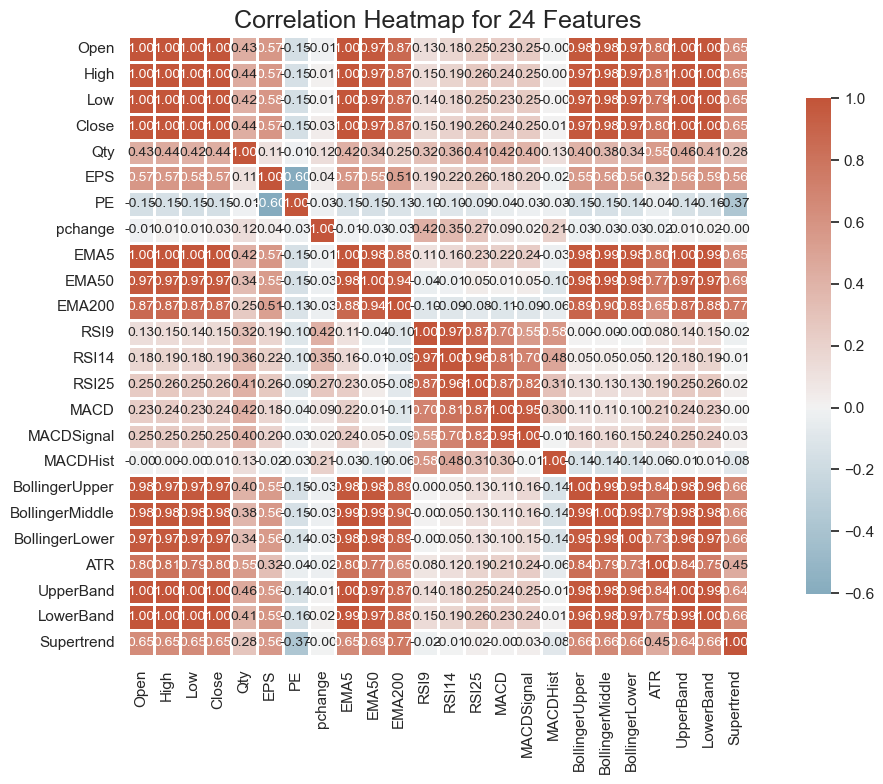

In [22]:
# Step 1: Calculate the correlation matrix
import seaborn as sns
corr_matrix = df.corr()

# Step 2: Plot the heatmap using Seaborn
plt.figure(figsize=(12, 8))  # Adjust size as per your dataset

# Create a custom diverging color palette
sns.set(style="white")  # Set style for better presentation
cmap = sns.diverging_palette(230, 20, as_cmap=True)  # Diverging color map

# Create heatmap with annotation and color intensity
sns.heatmap(corr_matrix, 
            annot=True,             # Annotate the values
            cmap=cmap,              # Use diverging palette for better clarity
            center=0,               # Center the colors around 0
            square=True,            # Square-shaped grid
            linewidths=0.8,         # Line width between cells
            fmt=".2f",              # Formatting for correlation values
            cbar_kws={"shrink": 0.8},  # Adjust color bar size
            annot_kws={"size": 10})    # Font size of annotations

# Step 3: Title and display the plot
plt.title(f'Correlation Heatmap for {len(df.columns)} Features', fontsize=18)
plt.tight_layout()  # Make sure everything fits
plt.show()

In [23]:
# to check numeric ways of this data:
# correlation_matrix = df.corr(numeric_only=True)
# print(correlation_matrix)

In [24]:

df.describe()

,Open,High,Low,Close,Qty,EPS,PE,pchange,EMA5,EMA50,...,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR,UpperBand,LowerBand,Supertrend
count,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,...,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000
mean,568.243200,574.946795,559.053830,565.995154,72199.473163,30.132501,32.350906,-0.008636,566.278540,568.215567,...,-1.178622,-1.318039,0.139417,604.840347,567.061907,529.283467,16.544938,616.530124,517.260496,528.661932
std,193.030373,195.024173,188.625419,191.073708,85038.827424,14.008393,48.426220,2.007748,190.479494,183.833510,...,15.816961,15.110209,4.756468,202.687199,188.990449,179.791978,7.873550,211.086549,173.437402,267.031179
min,295.000000,303.000000,285.000000,298.000000,60.000000,1.780000,9.367337,-24.753775,307.609469,316.347773,...,-72.596118,-62.477975,-29.053904,318.617976,312.450000,278.590077,4.709079,321.568248,269.038577,0.000000
25%,411.000000,415.000000,406.000000,410.050000,17448.500000,17.940000,14.665401,-1.005576,410.697886,409.998695,...,-9.988909,-9.898956,-1.897587,443.391313,411.725000,386.213798,10.706225,439.715151,378.196406,403.062918
50%,498.000000,505.000000,490.000000,497.000000,44108.000000,34.560000,18.719690,-0.170358,497.141227,497.869147,...,-1.743464,-1.665949,0.164881,530.189526,500.100000,458.144456,14.611203,547.352615,450.508939,462.651076
75%,730.000000,736.550000,720.100000,725.100000,91554.000000,40.220000,24.671145,0.816883,725.648318,735.304473,...,5.599151,5.667563,2.388123,787.246234,724.445000,681.418007,21.264004,787.154538,670.795507,696.491698
max,1080.000000,1085.000000,1046.000000,1073.000000,751075.000000,60.770000,285.955056,10.000000,1048.211252,982.959825,...,64.824889,60.612057,21.865225,1107.163095,1036.595000,1005.221541,46.924015,1166.238116,967.372098,948.802331


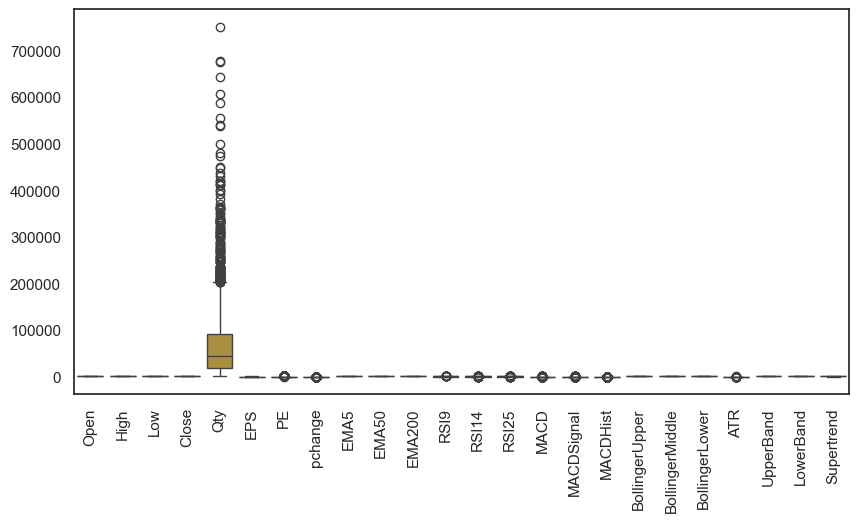

In [25]:
#Checking Outliers by box plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.boxplot(data=df)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.show()

* To remove outliers, we can use min max scaler to to range the values between certain values , also we use clip it using IQR and there are also other ways to remove ouliers

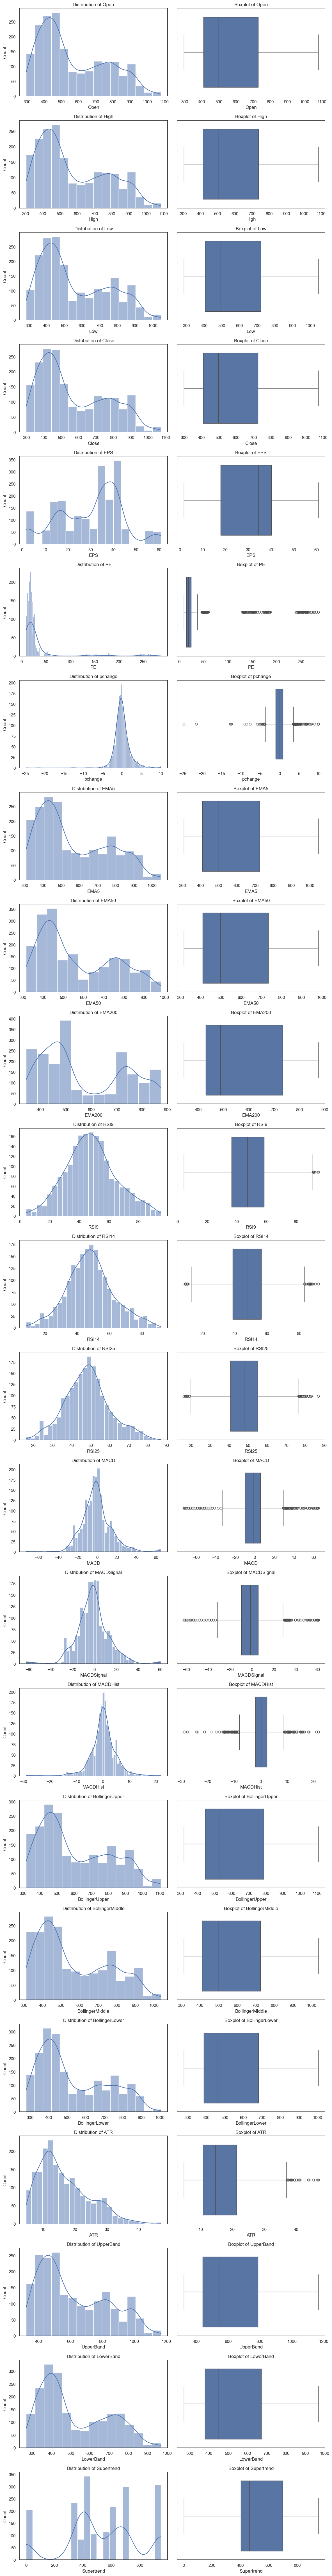

In [26]:
# Calculate rows needed based on the number of columns
numerical_data = df.select_dtypes(include=['float64'])
n_cols = len(numerical_data.columns)
n_rows = n_cols

# Adjust figsize dynamically
plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(numerical_data.columns):
    # Create a subplot for the distribution plot
    plt.subplot(n_rows, 2, 2 * i + 1)
    # sns.histplot(numerical_data[col], kde=True, bins=30)  # Updated to use sns.histplot
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
     # Create a subplot for the boxplot
    plt.subplot(n_rows, 2, 2 * i + 2)
    sns.boxplot(x=numerical_data[col])
    plt.title(f'Boxplot of {col}')

# Adjustjustment on  layout to prevent overlap
plt.tight_layout()
plt.show()

In [27]:
# def find_outliers_iqr_multiple_columns(df,columns):
#     """
#     Identify outliers in multiple specified columns of a data frame using the IQR method.
#     """
#     outliers_summary = {}

#     for column in columns:

#         percentile25 = df[column].quantile(0.25)
#         percentile75 = df[column].quantile(0.75)
#         iqr = percentile75 - percentile25
#         lower_limit = percentile25 - 1.5 * iqr
#         upper_limit = percentile75 + 1.5 * iqr


#         lower_outliers = df[df[column] < lower_limit]
#         upper_outliers = df[df[column] > upper_limit]

#         outliers_summary[column] = {
#             'lower_outliers_count': len(lower_outliers),
#             'upper_outliers_count': len(upper_outliers),
#             'lower_limit': lower_limit,
#             'upper_limit': upper_limit
#         }

#     return outliers_summary
# columns = df.select_dtypes(include=['float64', 'int64'])
# outliers_summary = find_outliers_iqr_multiple_columns(df, columns)


# for column, summary in outliers_summary.items():
#     print(f"\nColumn: {column}")
#     print(f"Lower Outliers Count: {summary['lower_outliers_count']}")
#     print(f"Upper Outliers Count: {summary['upper_outliers_count']}")
#     print(f"Lower Limit: {summary['lower_limit']}")
#     print(f"Upper Limit: {summary['upper_limit']}")

In [28]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Check for outliers in stock prices
for col in df:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col} - Outliers Found: {len(outliers)}")

Open - Outliers Found: 0
High - Outliers Found: 0
Low - Outliers Found: 0
Close - Outliers Found: 0
Qty - Outliers Found: 139
EPS - Outliers Found: 0
PE - Outliers Found: 193
pchange - Outliers Found: 116
EMA5 - Outliers Found: 0
EMA50 - Outliers Found: 0
EMA200 - Outliers Found: 0
RSI9 - Outliers Found: 12
RSI14 - Outliers Found: 37
RSI25 - Outliers Found: 38
MACD - Outliers Found: 95
MACDSignal - Outliers Found: 82
MACDHist - Outliers Found: 134
BollingerUpper - Outliers Found: 0
BollingerMiddle - Outliers Found: 0
BollingerLower - Outliers Found: 0
ATR - Outliers Found: 27
UpperBand - Outliers Found: 0
LowerBand - Outliers Found: 0
Supertrend - Outliers Found: 0


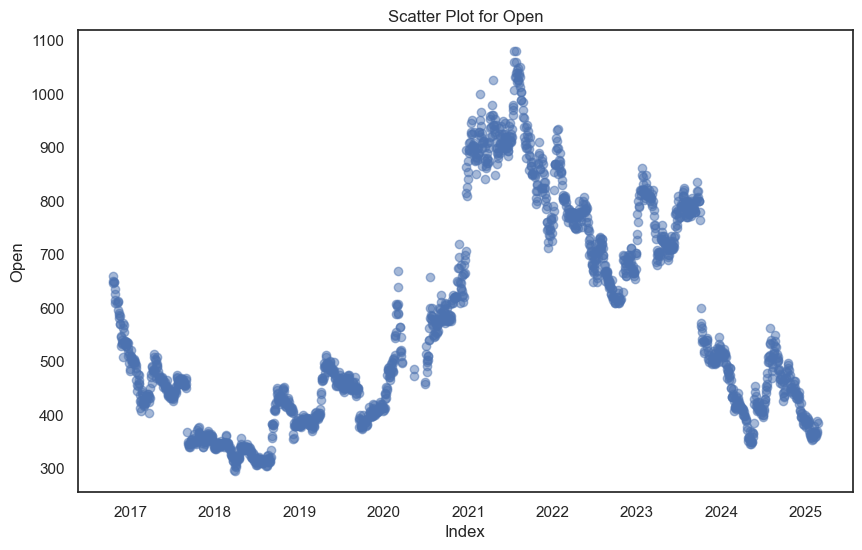

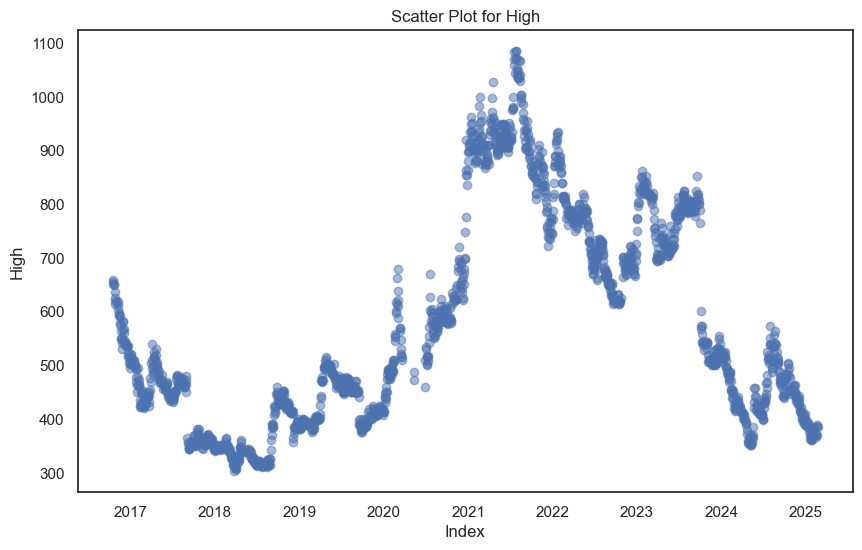

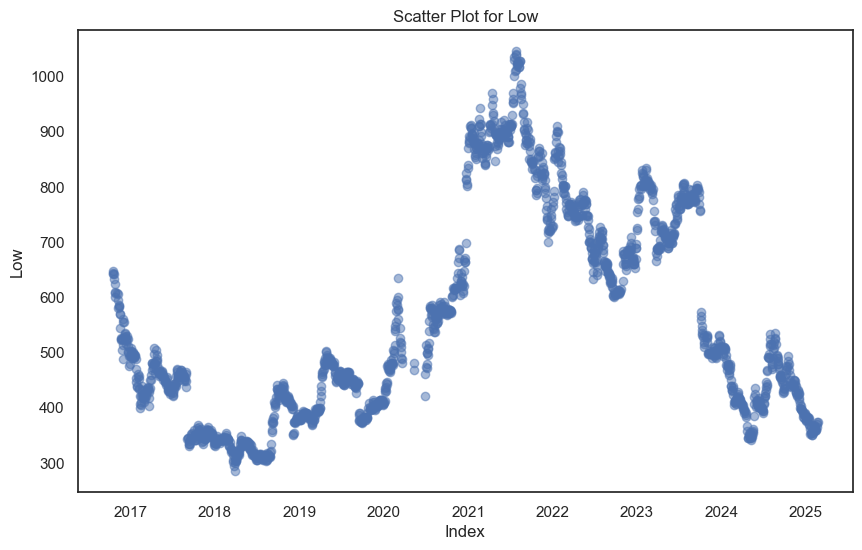

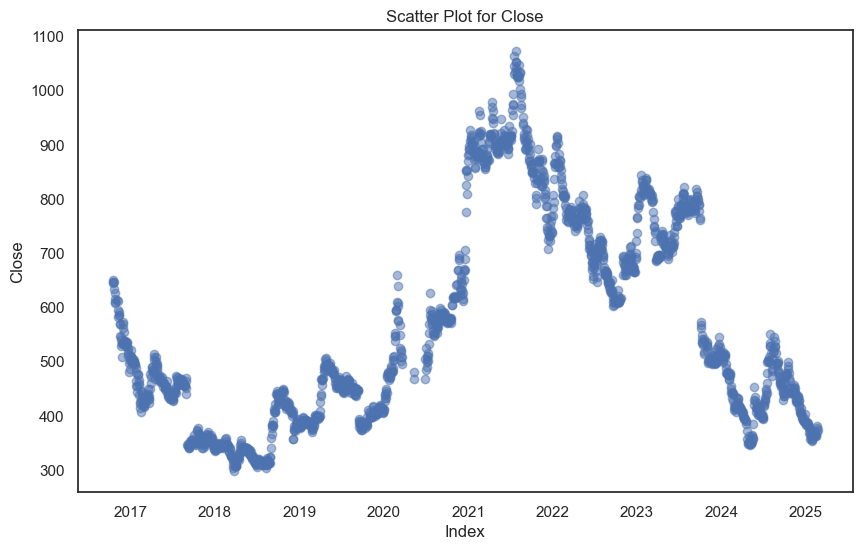

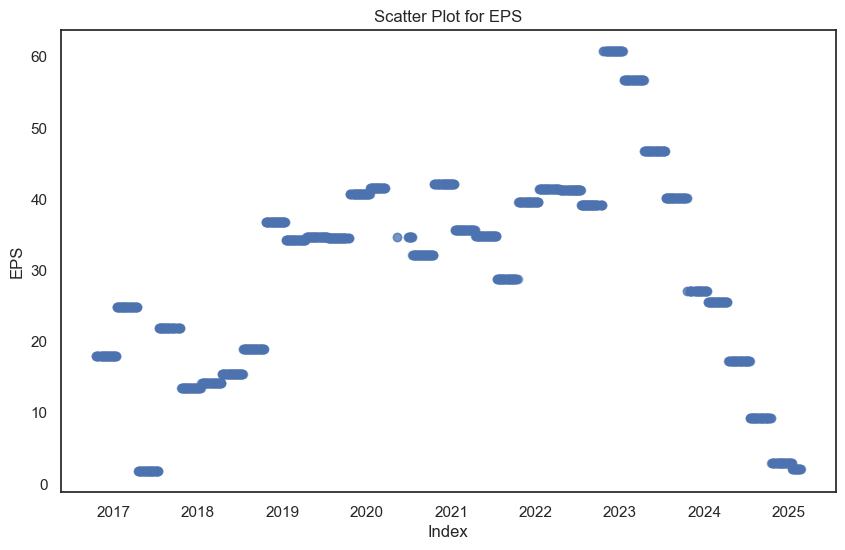

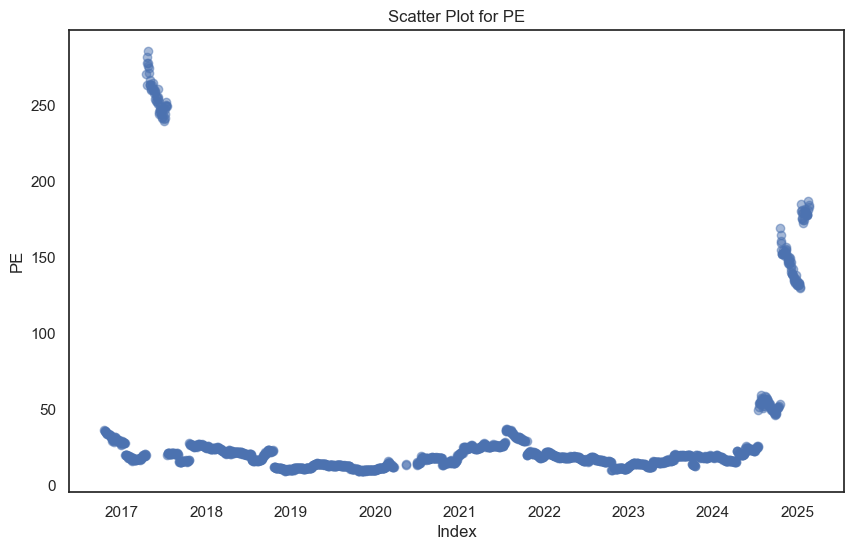

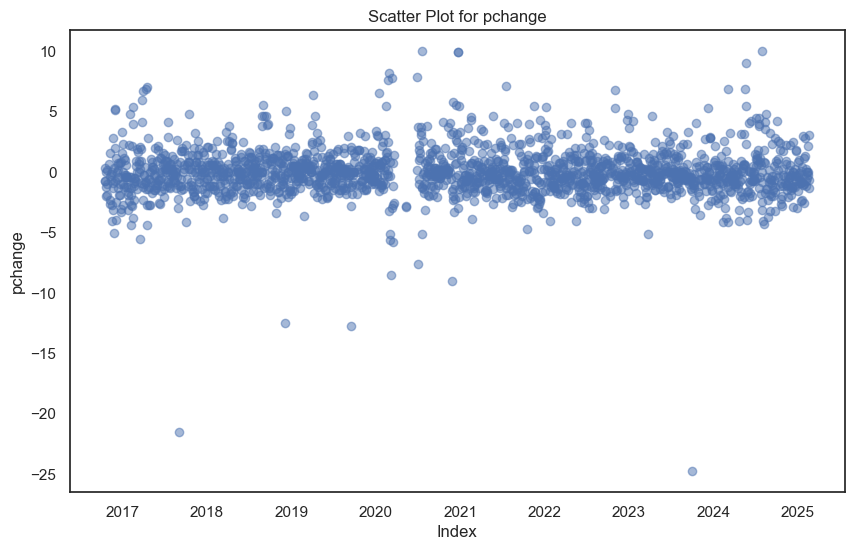

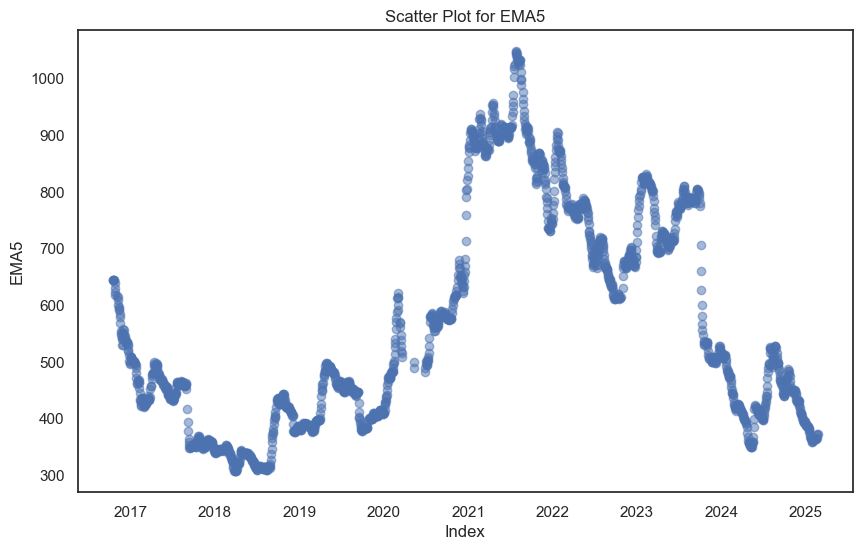

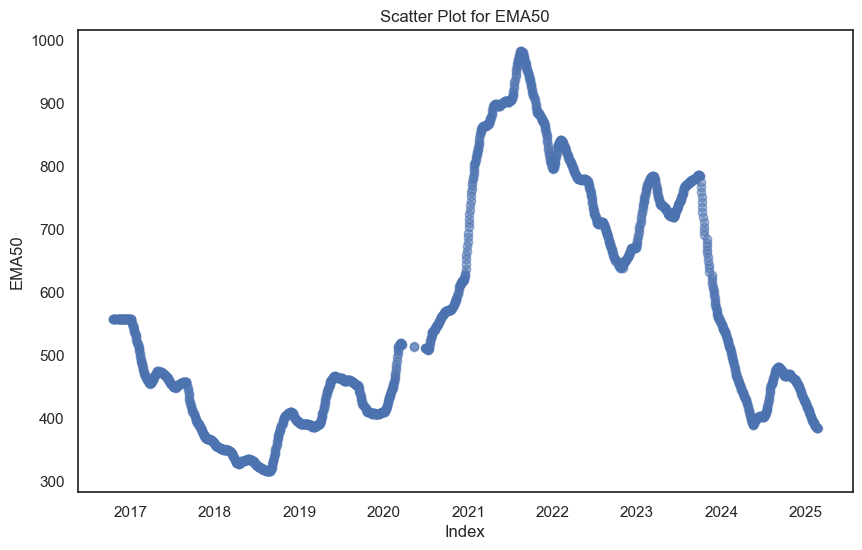

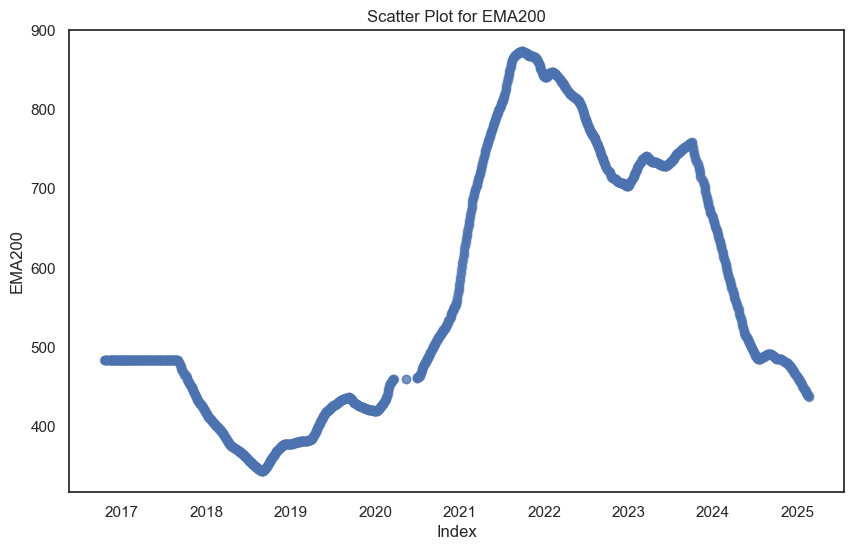

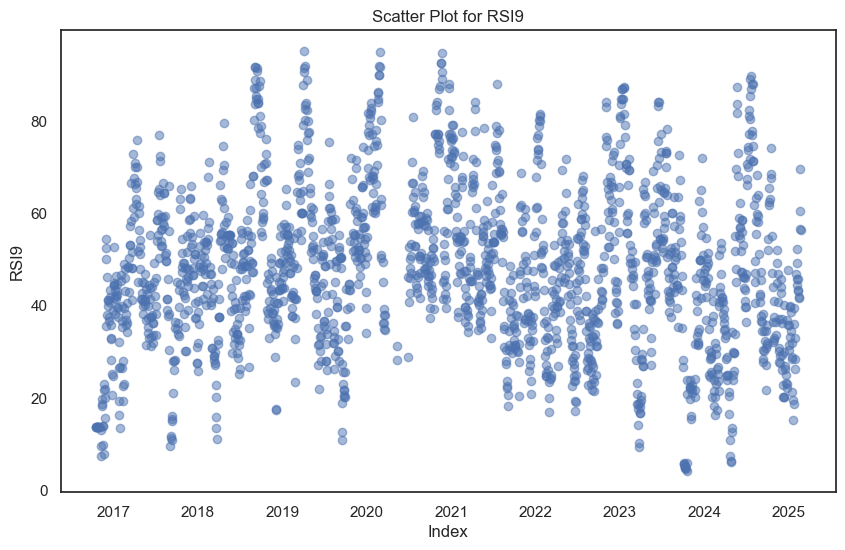

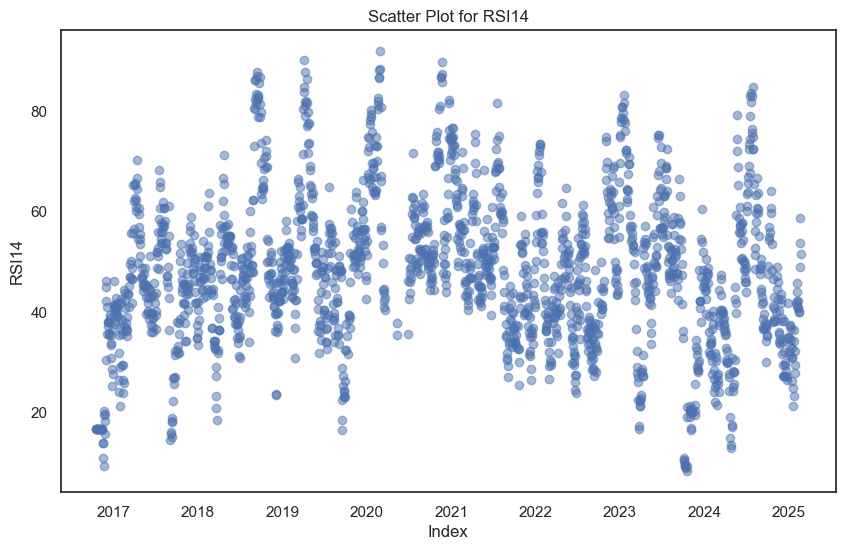

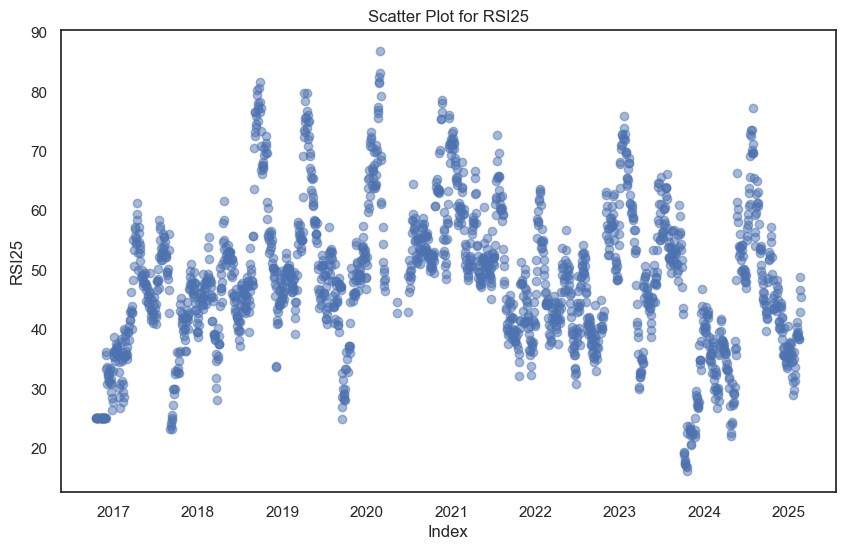

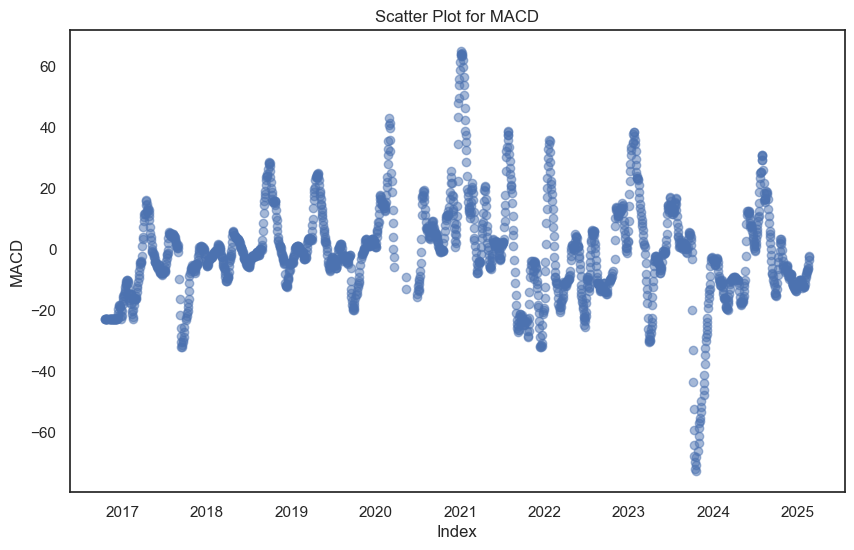

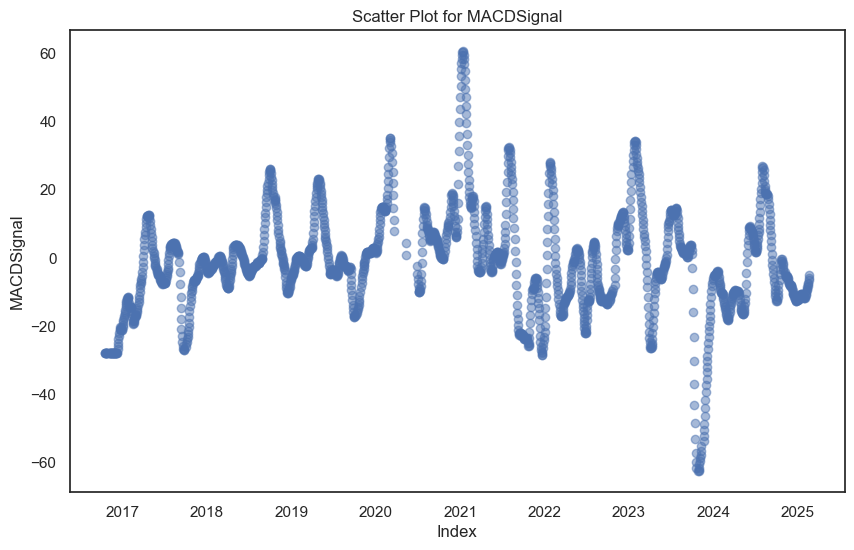

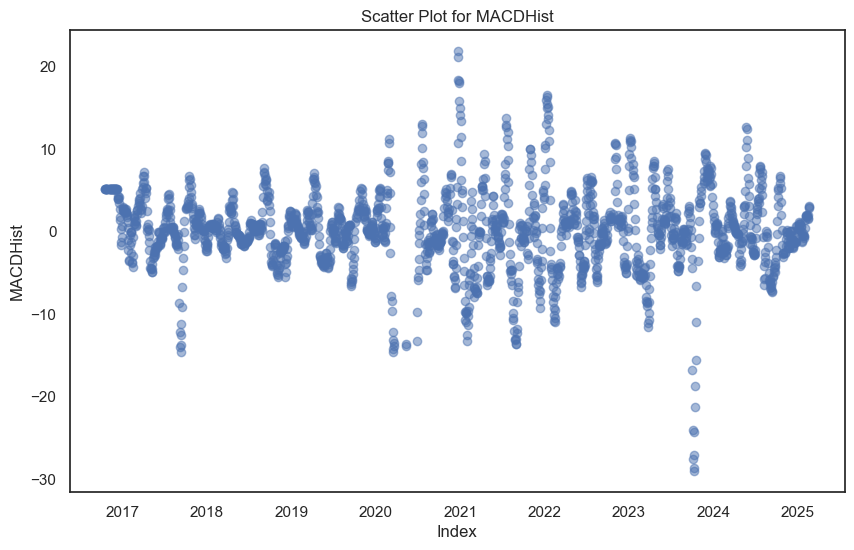

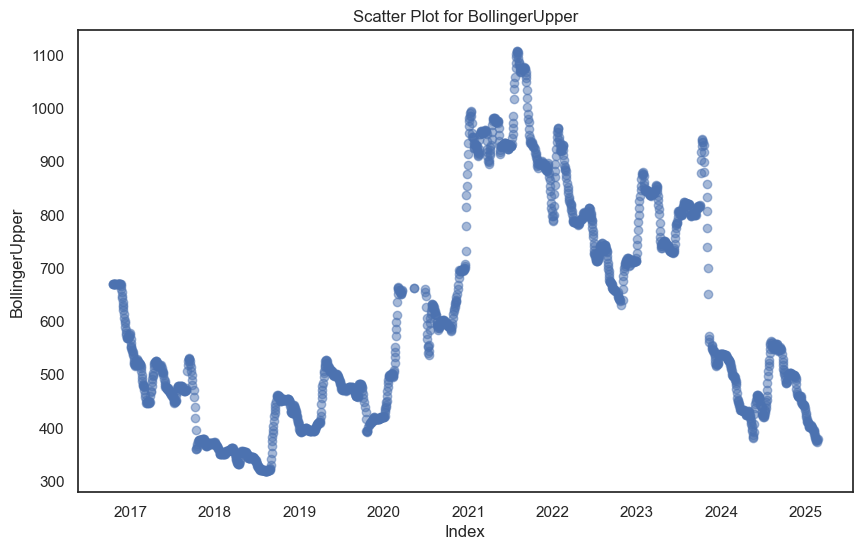

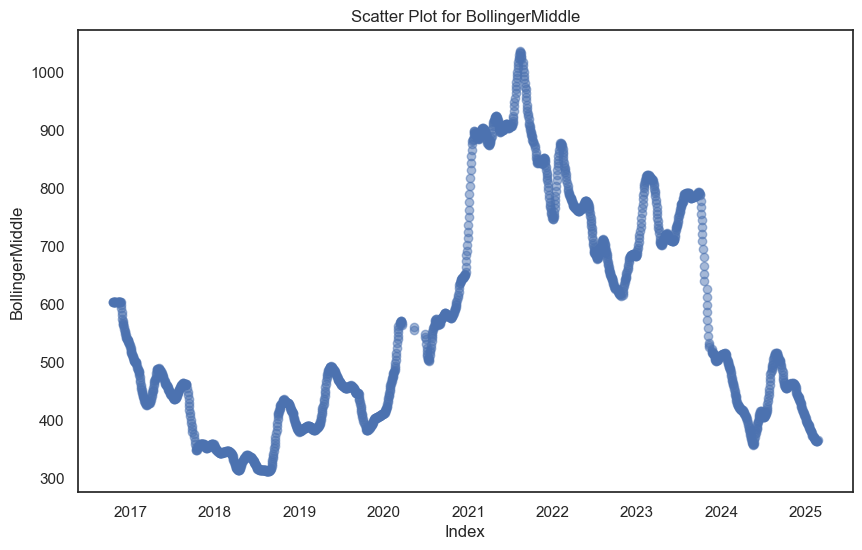

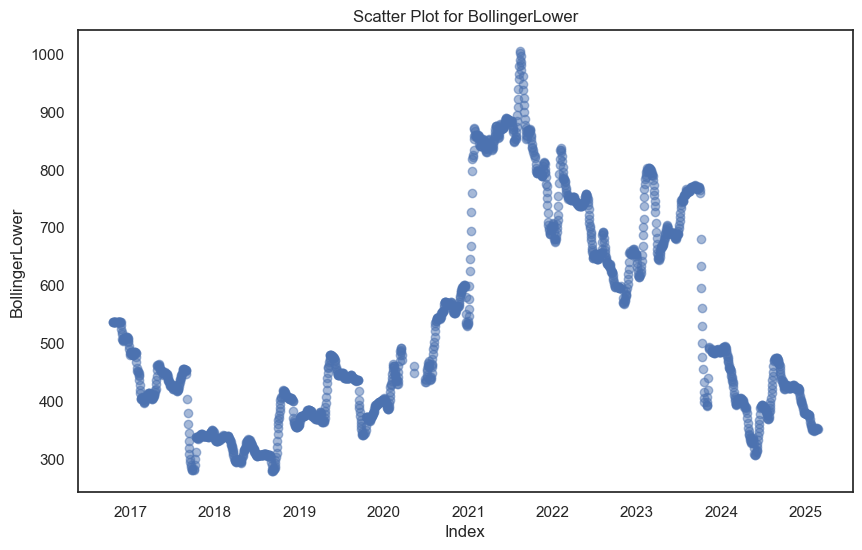

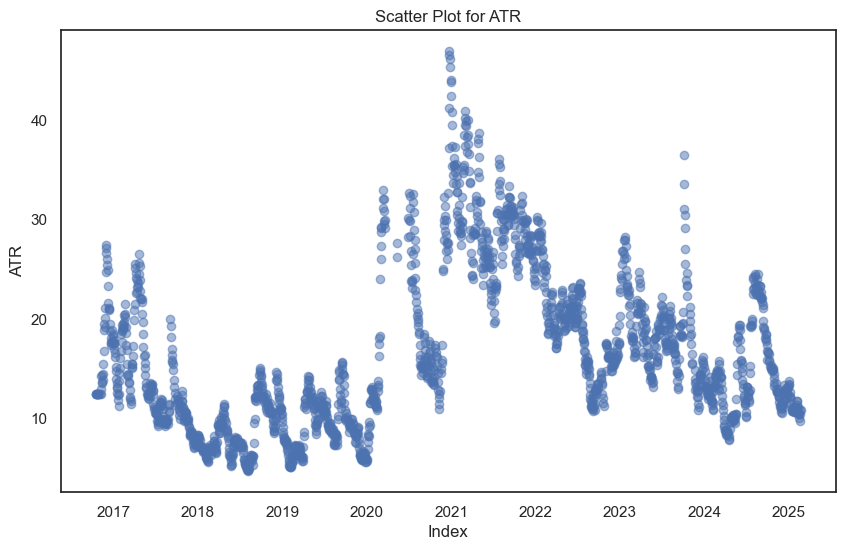

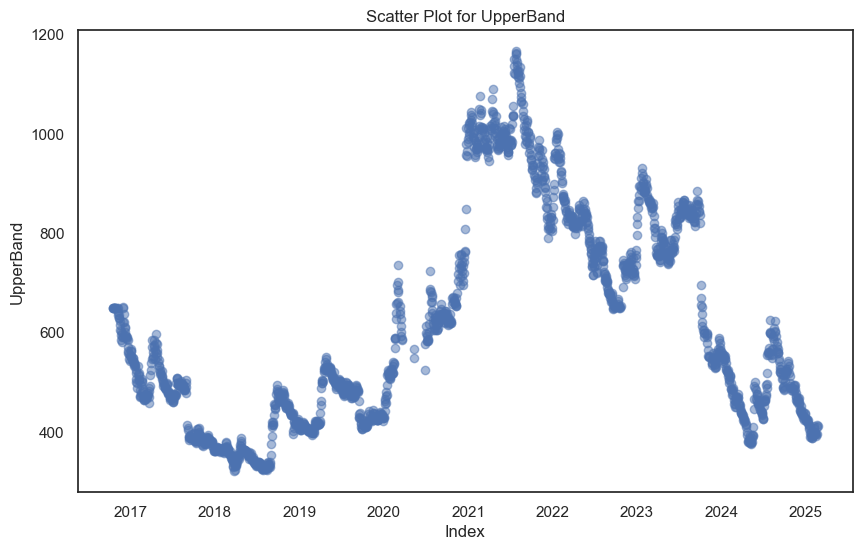

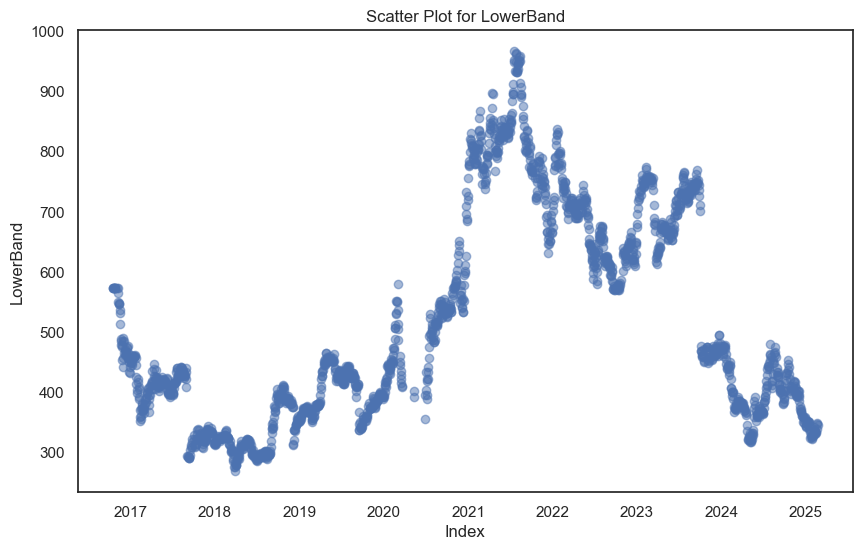

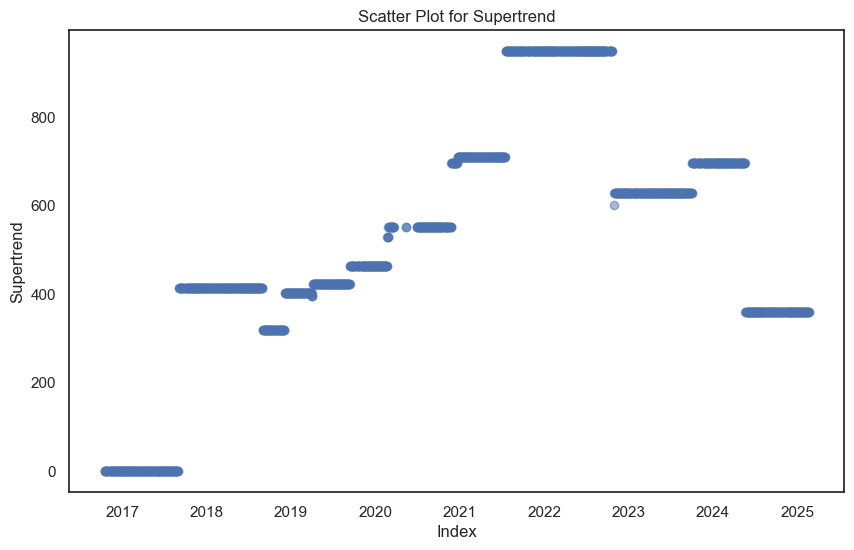

In [29]:
import matplotlib.pyplot as plt

# Plot scatter plot for each numerical column to check for outliers
for column in numerical_data.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df.index, df[column], alpha=0.5)
    plt.title(f'Scatter Plot for {column}')
    plt.xlabel('Index')
    plt.ylabel(column)
    plt.show()

In [30]:
#removing outliers

# for col in df:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     df[col] = df[col].clip(lower_bound, upper_bound)

#note: as data is taken from authenticated source, so outliers are not removed because it might have some important information.

In [31]:
# #checking outliers after removing it from above code:
# def detect_outliers_iqr(data, column):
#     Q1 = data[column].quantile(0.25)
#     Q3 = data[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
#     return outliers

# # Check for outliers in stock prices
# for col in df:
#     outliers = detect_outliers_iqr(df, col)
#     print(f"{col} - Outliers Found: {len(outliers)}")

#note: not checked as outliers are not removed

In [32]:
#after removing outliers, checking box plot again:

# plt.figure(figsize=(10, 5))
# sns.boxplot(data=df)
# plt.xticks(rotation=90)  # Rotate x-axis labels for readability
# plt.show()

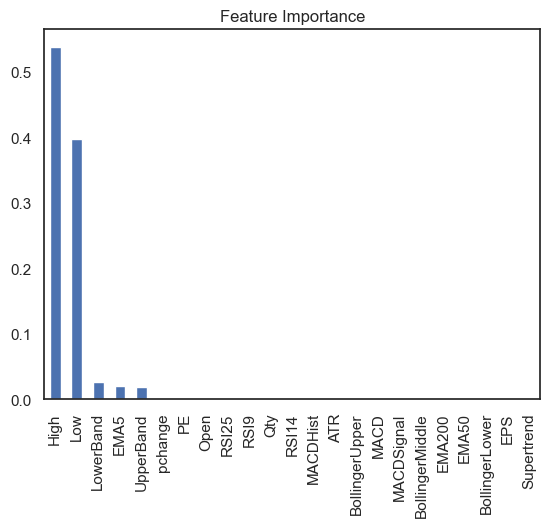

In [33]:
#checking feature imortance:
from sklearn.ensemble import RandomForestRegressor

# Select numerical columns
features = df.columns.drop(['Close'])
X = df[features]
y = df['Close']

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()


This code is used when you want to analyze which factors influence the stock closing price and build a predictive model using Random Forest Regression.

In [34]:
import numpy as np
import pandas as pd
from pandas.plotting import lag_plot
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [35]:
close = df['Close']
result = seasonal_decompose(close, model='additive', period=30)

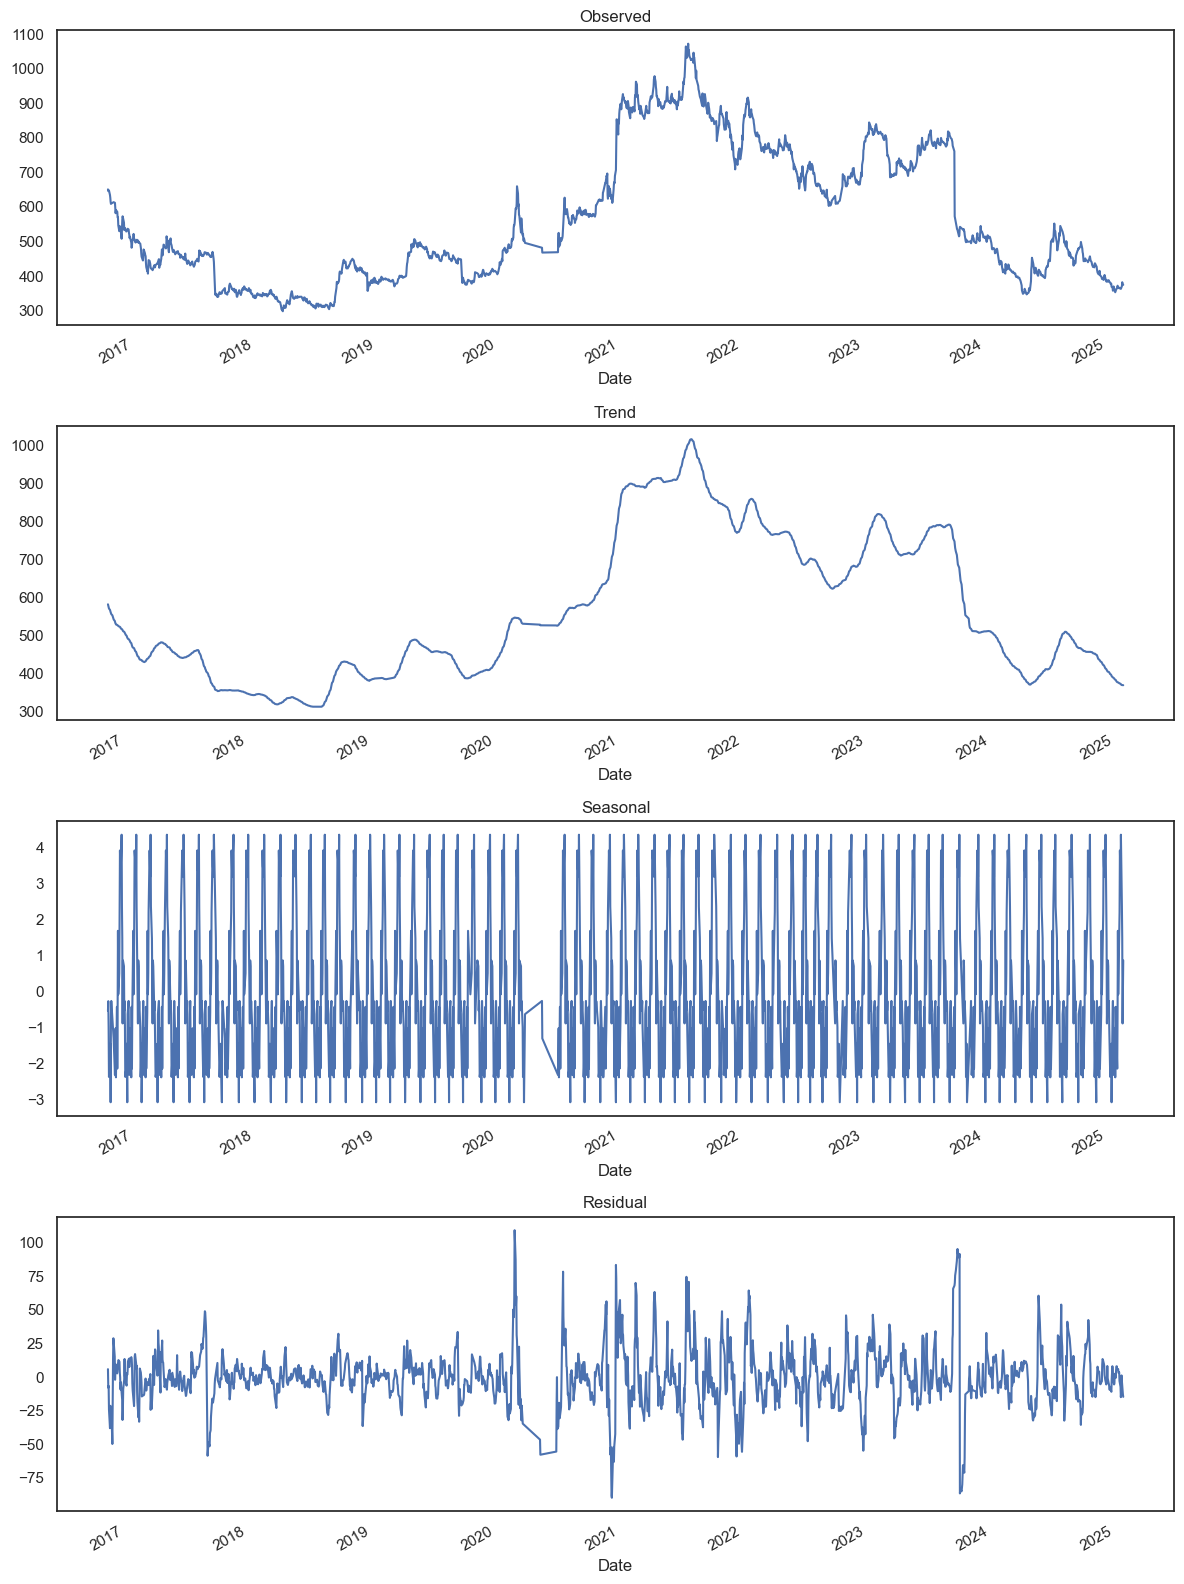

In [36]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16))
result.observed.plot(ax=ax1)
ax1.set_title('Observed')
result.trend.plot(ax=ax2)
ax2.set_title('Trend')
result.seasonal.plot(ax=ax3)
ax3.set_title('Seasonal')
result.resid.plot(ax=ax4)
ax4.set_title('Residual')
plt.tight_layout()
plt.show()

*  Interpretation of Each Component
* 1) Observed Plot (Top Graph)
*  Represents the raw time series data.

* We see an overall trend + seasonal variations (ups and downs).
* There are fluctuations indicating price movements over time.
* 2) Trend Component (Second Graph)
*  Shows the long-term movement in the data (upward/downward trends).

* There was an uptrend from 2020 to 2022, followed by a downtrend.
* This is useful for detecting if the data follows a structural pattern over time.
* * A strong trend component suggests ARIMA or LSTM might be useful.
* 3) Seasonal Component (Third Graph)
*  Captures repeating patterns at regular intervals.

* The data exhibits strong seasonality, with repeating cycles.
* There’s a disruption around 2021, possibly due to external events (e.g., market crashes, missing data).
* If seasonality is present, SARIMA (Seasonal ARIMA) or LSTMs with periodic inputs could be useful.
* 4) Residual Component (Fourth Graph)
* Represents random noise (unpredictable movements).

* Large residual spikes indicate periods of high volatility.
* If residuals are randomly distributed, the model successfully captures trend & seasonality.
* If residuals show patterns, the model might need improvement.

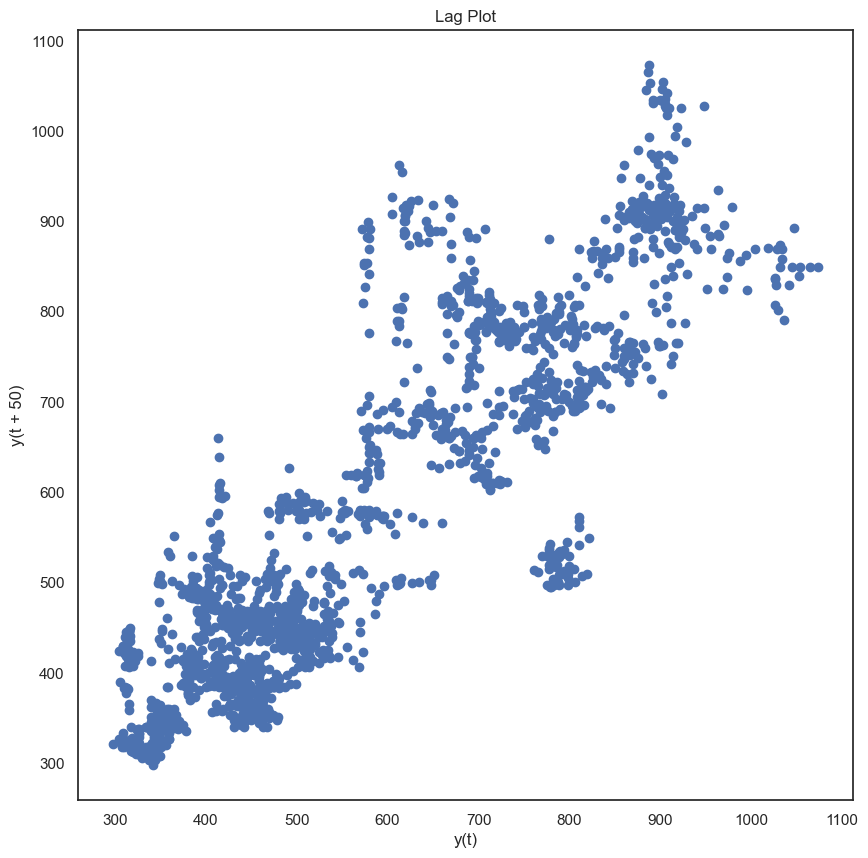

In [37]:
#lag plot
plt.figure(figsize=(10, 10))
lag_plot(close,lag=50) #check lag values at different steps to decide time-steps ie taking prev days values
plt.title('Lag Plot')
plt.show()

In [38]:
# We have not introduced ACF and PACF plots .
#plot of Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
# plot_acf(close, ax=ax1, lags=100)
# plot_pacf(close, ax=ax2, lags=100)
# plt.tight_layout()
# plt.show()

* Since ACF shows long-term dependence, use at least 60+ timesteps.
* Scaling is required to improve convergence.
### Observation:
* The ACF plot shows strong autocorrelation across all lags (gradual decline).
* This suggests a non-stationary time series (likely a trend or seasonality).
* To make the series stationary, differencing may be needed.


* ACF Analysis (Top Graph)
* Strong autocorrelation at all lags (slow decay) → Suggests a trend (non-stationary).
* Solution: Apply differencing (d=1) and recheck ACF.
* PACF Analysis (Bottom Graph)
* Strong spike at lag 1, then quick drop → Suggests an AR(1) process.
* Solution: Try ARIMA(1,1,0) after differencing.

In [39]:
#breaking into year monnth day and dayofweek
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['dayofweek'] = df.index.dayofweek

<Axes: xlabel='year'>

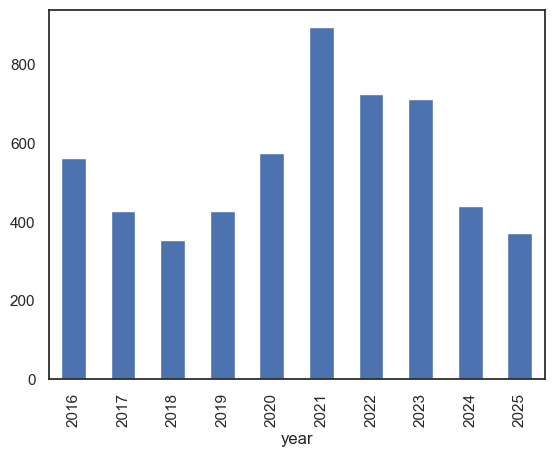

In [40]:
###################
# Yearly Close of nic

df.groupby('year')['Close'].mean().plot.bar()

<Axes: xlabel='month'>

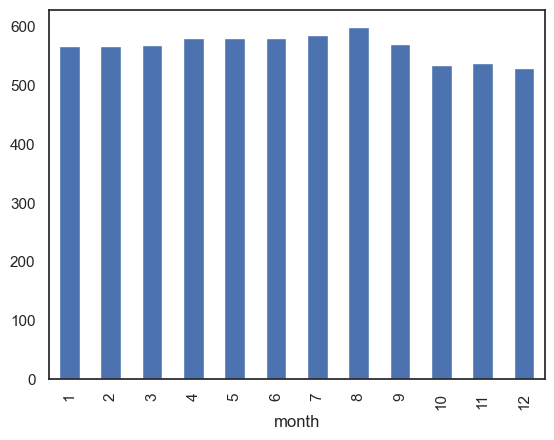

In [41]:
df.groupby('month')['Close'].mean().plot.bar()

<Axes: xlabel='day'>

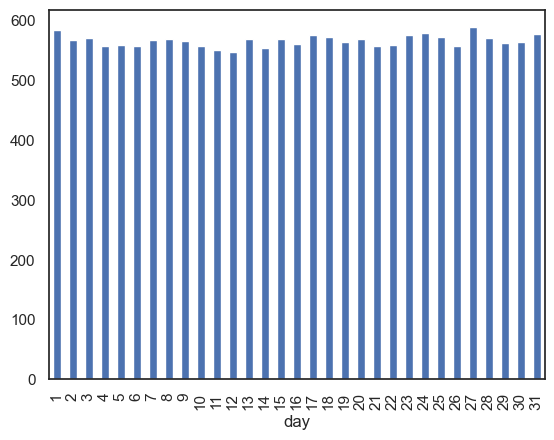

In [42]:
df.groupby('day')['Close'].mean().plot.bar()

<Axes: xlabel='dayofweek'>

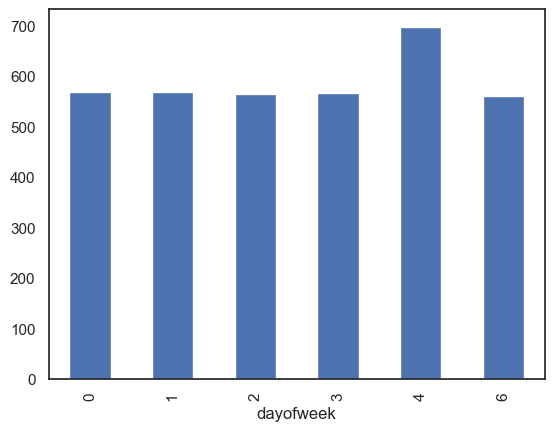

In [43]:
df.groupby('dayofweek')['Close'].mean().plot.bar()

In [44]:
df.head(1)

,Open,High,Low,Close,Qty,EPS,PE,pchange,EMA5,EMA50,...,BollingerMiddle,BollingerLower,ATR,UpperBand,LowerBand,Supertrend,year,month,day,dayofweek
Date,,,,,,,,,,,,,,,,,,,,,
2016-10-17,660.0,660.0,647.0,651.0,5758,17.94,36.287625,-0.768049,645.6,558.32,...,603.7,537.297892,12.5,649.5,574.5,0.0,2016,10,17,0


In [45]:
df.drop(['year', 'month', 'day', 'dayofweek'], axis=1, inplace=True)

In [46]:
#data split

In [47]:
# Ensure all  columns are present (adjust if needed)
feature_columns = df.columns # Your 8 features
data = df[feature_columns].values
feature_columns,len(feature_columns)

(Index(['Open', 'High', 'Low', 'Close', 'Qty', 'EPS', 'PE', 'pchange', 'EMA5',
        'EMA50', 'EMA200', 'RSI9', 'RSI14', 'RSI25', 'MACD', 'MACDSignal',
        'MACDHist', 'BollingerUpper', 'BollingerMiddle', 'BollingerLower',
        'ATR', 'UpperBand', 'LowerBand', 'Supertrend'],
       dtype='object'),
 24)

### yaha samn same............................................................................

In [48]:
# Scale all 8 features between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [49]:
# Sequence creation function
def create_sequences_multivariate(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])   # n_steps timesteps, each with 8 features
        y.append(data[i+n_steps])      # Predict all 8 features at next step
    return np.array(X), np.array(y)

In [50]:
# Parameters
n_steps = 60  # Past 60 days used for prediction
# Create sequences
X, y = create_sequences_multivariate(scaled_data, n_steps)

In [51]:
# Train-test split
split = int(len(X) * 0.9)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [52]:
X_train.shape, X_test.shape

((1673, 60, 24), (186, 60, 24))

#### Building LSTM Modlel

In [53]:
# Define Bidirectional LSTM model
model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(n_steps, X_train.shape[2])),
    Dropout(0.2),
    LSTM(128, activation='tanh', return_sequences=True),
    Dropout(0.3),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.3),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(X_train.shape[2])
    
])
model.compile(optimizer='adam', loss='mse')

d:\ml\mlproject\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2)
]
# Train the model
lstmModel = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=64,
                    callbacks=callbacks)


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - loss: 0.1496 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0495 - val_loss: 0.0157 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0351 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0273 - val_loss: 0.0126 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0245 - val_loss: 0.0122 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0227 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0206 - val_loss: 0.0129 - learning_rate: 0.0010
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0194 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0176 - val_loss: 0.0105 - learning_rate: 0.0010
Epo

In [55]:
from datetime import datetime

# Get current date and time
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
model.save(f'DATE{current_time}indicatorsfinal_model_60.keras')

In [56]:
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
# model = load_model(f'indicatorsfinal_model_60.keras')

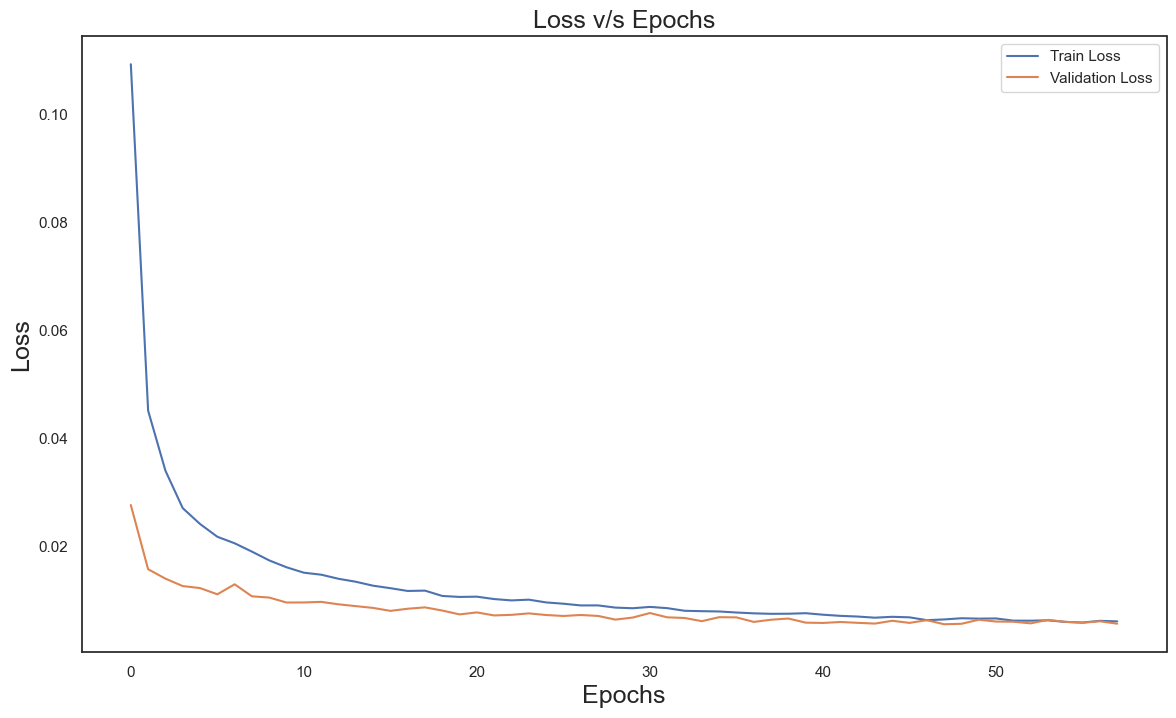

In [57]:
# Plot training & validation loss

plt.figure(figsize=(14, 8))
plt.plot(lstmModel.history['loss'], label='Train Loss')
plt.plot(lstmModel.history['val_loss'], label='Validation Loss')
plt.title('Loss v/s Epochs', fontsize=18)
plt.ylabel('Loss',fontsize=18)
plt.xlabel('Epochs',fontsize=18)
plt.legend()
plt.show()

In [58]:
## for the X_train
train_result=model.predict(X_train)
train_result_inverse=scaler.inverse_transform(train_result)
train_result_close=train_result_inverse[:, 3]

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step


In [59]:
## for the X_test
test_result=model.predict(X_test)
test_result_inverse=scaler.inverse_transform(test_result)
test_result_close=test_result_inverse[:, 3]

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [60]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
#for close price
print("MAE of close price:", mean_absolute_error(y_test[:,3], test_result[:,3]))
print("R² Score of close price:", r2_score(y_test[:,3], test_result[:,3]))
print("MSE of close price:", mean_squared_error(y_test[:,3], test_result[:,3]))
print("MAPE of close price:", mean_absolute_percentage_error(y_test[:,3], test_result[:,3]))
print("RMSE of close price:", np.sqrt(mean_squared_error(y_test[:,3], test_result[:,3])))


MAE of close price: 0.03027668623279418
R² Score of close price: 0.6234835504914267
MSE of close price: 0.001585380949966514
MAPE of close price: 0.1842314430184186
RMSE of close price: 0.03981684254139841


In [61]:
#for all features
print("MAE of Test:", mean_absolute_error(y_test, test_result))
print("R² Score TESt:", r2_score(y_test, test_result))
print("MSE TESt:", mean_squared_error(y_test, test_result))
print("MAPE of Test:", mean_absolute_percentage_error(y_test, test_result))
print("RMSE of close price:", np.sqrt(mean_squared_error(y_test, test_result)))


MAE of Test: 0.04869323446397059
R² Score TESt: 0.5098340515836673
MSE TESt: 0.006689601353119517
MAPE of Test: 0.46862605507815375
RMSE of close price: 0.08178998320772243


In [62]:
#for training dataset

print("MAE of Train:", mean_absolute_error(y_train, train_result))
print("R² Score Train:", r2_score(y_train, train_result))
print("MSE Train:", mean_squared_error(y_train, train_result))
print("MAPE of Train:", mean_absolute_percentage_error(y_train, train_result))
print("MSE Train:", np.sqrt(mean_squared_error(y_train, train_result)))



MAE of Train: 0.03546749031048927
R² Score Train: 0.8402335042092691
MSE Train: 0.003204045920659478
MAPE of Train: 2052423706898.929
MSE Train: 0.05660429242256702


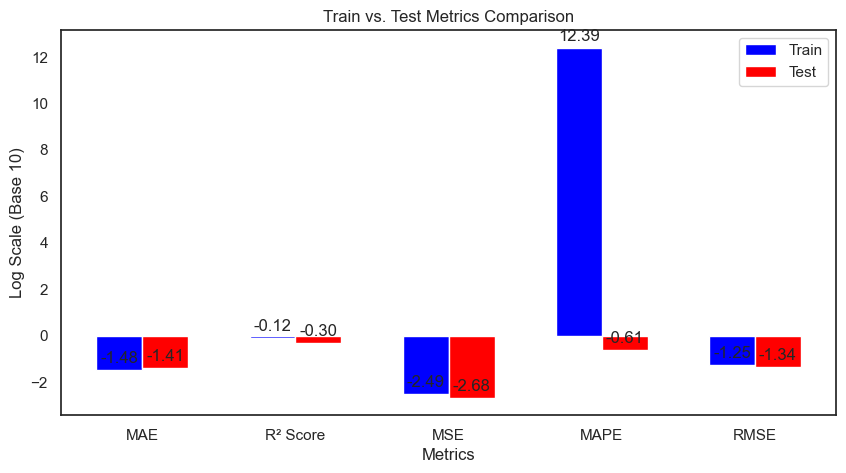

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics values
metrics = ['MAE', 'R² Score', 'MSE', 'MAPE', 'RMSE']
train_values = [0.03285, 0.7509, 0.00320, 2471872178591.562, 0.05663]
test_values = [0.03900, 0.4985, 0.00211, 0.2478, 0.04595]

# Fix scale issue (log scale for MAPE due to huge difference)
log_train_values = np.log10(train_values)
log_test_values = np.log10(test_values)

# Bar plot
x = np.arange(len(metrics))
width = 0.3  # Bar width

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, log_train_values, width, label='Train', color='blue')
bars2 = ax.bar(x + width/2, log_test_values, width, label='Test', color='red')

# Labels
ax.set_xlabel('Metrics')
ax.set_ylabel('Log Scale (Base 10)')
ax.set_title('Train vs. Test Metrics Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Show values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', 
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


In [64]:
X_test.shape, X_train.shape, y_test.shape, y_train.shape

((186, 60, 24), (1673, 60, 24), (186, 24), (1673, 24))

In [65]:
# Function to predict future days recursively (all features)

def predict_future_multivariate(model, data, scaler, n_steps, future_days):
    predicted = []
    current_sequence = data[-n_steps:]  # Last window of data

    for _ in range(future_days):
        prediction = model.predict(current_sequence.reshape(1, n_steps, X_train.shape[2]), verbose=0)
        predicted.append(prediction[0])

        # Append predicted row to current sequence for next prediction
        current_sequence = np.vstack([current_sequence[1:], prediction])

    # Inverse transform all predicted data (8 features)
    predicted_array = np.array(predicted)
    predicted_prices = scaler.inverse_transform(predicted_array)
    return predicted_prices

In [66]:
# Predict next 30 days
future_days = 50
future_prices = predict_future_multivariate(model, scaled_data, scaler, n_steps, future_days)

In [67]:
n_steps

60

In [68]:
scaled_data.shape

(1919, 24)

In [69]:
test_result.shape, train_result.shape, future_prices.shape,test_result_close.shape, train_result_close.shape

((186, 24), (1673, 24), (50, 24), (186,), (1673,))

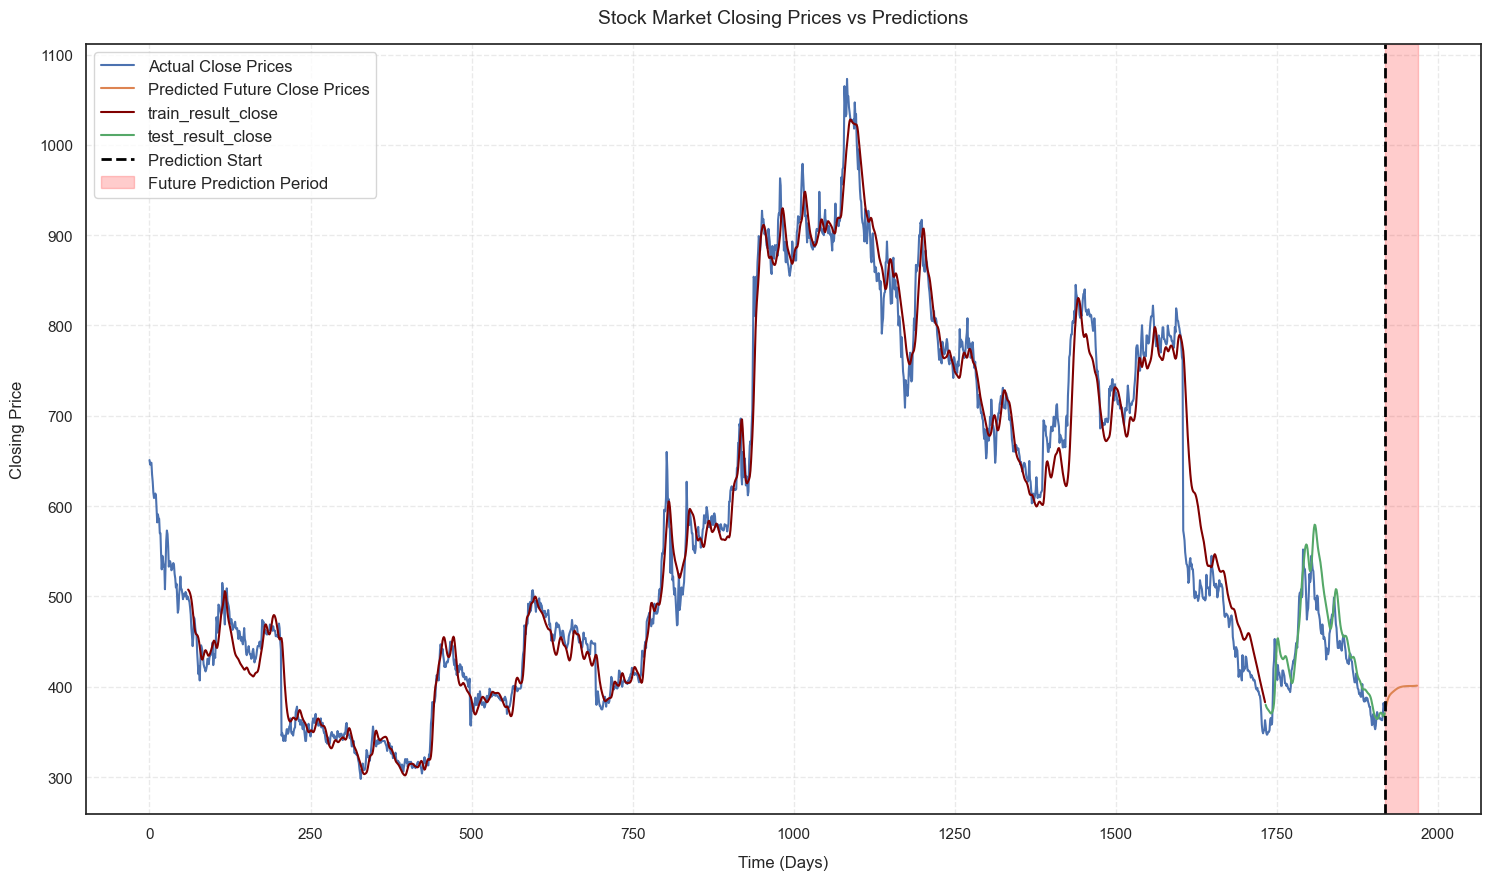

In [70]:
# Plot actual vs future Close prices

actual_close_prices = df['Close'].values
plt.figure(figsize=(18, 10))
plt.plot(actual_close_prices, label='Actual Close Prices')
plt.plot(range(len(actual_close_prices), len(actual_close_prices) + future_days), future_prices[:, 3], label='Predicted Future Close Prices')
plt.plot(range(n_steps, len(train_result_close)+n_steps),train_result_close,label="train_result_close", color="maroon" )
plt.plot(range(len(train_result_close)+n_steps, len(train_result_close)+len(test_result_close)+n_steps),test_result_close,label="test_result_close" )

plt.axvline(x=len(df), color='black', linestyle='--', linewidth=2, label="Prediction Start")

plt.axvspan(len(df), len(df)+future_days, color='red', alpha=0.2, label="Future Prediction Period")
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlabel("Time (Days)", fontsize=12, labelpad=10)
plt.ylabel("Closing Price", fontsize=12, labelpad=10)
plt.title("Stock Market Closing Prices vs Predictions", fontsize=14, pad=15)
plt.legend(fontsize=12, loc="upper left")

In [71]:
# Print predicted future prices (all features for each day)
future_df = pd.DataFrame(future_prices, columns=feature_columns)
future_df

,Open,High,Low,Close,Qty,EPS,PE,pchange,EMA5,EMA50,...,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR,UpperBand,LowerBand,Supertrend
0,372.853394,386.703217,368.464081,374.528778,13048.464844,11.470557,88.594727,-0.084261,367.954987,394.007629,...,-3.272458,-4.041997,3.303920,388.938354,374.328979,336.172180,10.020727,409.089325,355.264130,297.191559
1,376.887268,391.105865,372.584137,378.307434,17080.330078,11.853498,87.403664,-0.018512,372.046661,394.482056,...,-1.927900,-2.794069,3.654655,391.756378,375.988434,337.281616,10.043105,413.606079,358.766724,297.086060
2,380.217377,394.630554,375.937531,381.703613,20647.212891,12.304343,85.317902,0.003630,375.479797,394.457794,...,-0.758358,-1.710536,3.878154,394.031464,377.406860,338.324097,10.020100,416.934570,361.843994,297.216125
3,382.676300,397.126190,378.400085,384.530853,23622.937500,12.833740,82.285538,-0.014460,378.111389,393.924347,...,0.187113,-0.825659,3.967808,395.718079,378.515564,339.283142,9.941988,418.979156,364.359131,297.807037
4,384.328217,398.692749,380.076385,386.789093,26041.306641,13.441551,78.409462,-0.063813,380.027252,392.976166,...,0.912780,-0.125962,3.940287,396.915558,379.322327,340.166992,9.814022,419.912964,366.328674,298.889862
5,385.325500,399.529175,381.152954,388.566010,27997.341797,14.118509,73.872978,-0.134727,381.402618,391.742615,...,1.446378,0.419774,3.819429,397.773529,379.864807,340.988373,9.649158,419.993622,367.832001,300.351013
6,385.837677,399.837982,381.815460,389.962433,29589.392578,14.844989,68.911728,-0.218775,382.416809,390.348724,...,1.822694,0.845598,3.627725,398.428284,380.194092,341.765503,9.463694,419.485443,368.959656,302.007233
7,386.019318,399.792633,382.219971,391.069153,30902.478516,15.597108,63.763374,-0.309469,383.219604,388.900604,...,2.075843,1.181562,3.384044,398.990051,380.366241,342.518982,9.273568,418.624542,369.795288,303.680481
8,385.997559,399.536163,382.489410,391.967072,32008.328125,16.354206,58.623272,-0.401758,383.925049,387.484955,...,2.236664,1.451532,3.104264,399.549072,380.437469,343.269196,9.091868,417.602112,370.409698,305.254333
9,385.873779,399.180756,382.715851,392.724304,32966.058594,17.100401,53.637329,-0.491805,384.613129,386.168701,...,2.331810,1.673806,2.801776,400.174561,380.461548,344.035309,8.928205,416.567505,370.861725,306.682343


In [72]:
# Save to CSV if needed
# future_df.to_csv(f'{current_time}predicted_future_prices.csv', index=False)

In [73]:
df['Close'].tail(),future_df['Close'].head()

(Date
 2025-02-13    363.0
 2025-02-16    370.7
 2025-02-17    382.0
 2025-02-18    377.0
 2025-02-20    374.5
 Name: Close, dtype: float64,
 0    374.528778
 1    378.307434
 2    381.703613
 3    384.530853
 4    386.789093
 Name: Close, dtype: float32)

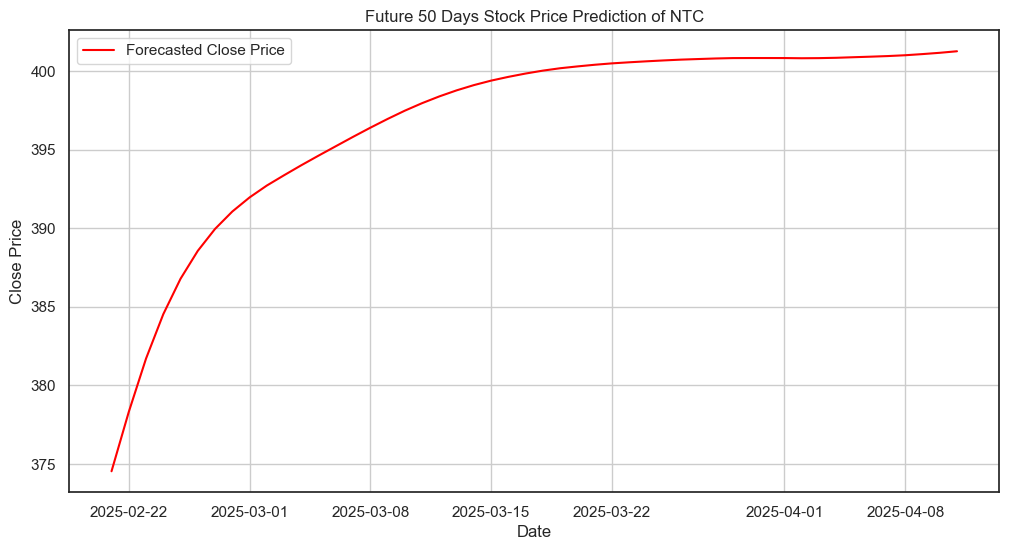

In [74]:
# Plot forecasted values
# Convert to NumPy
future_predictions_close = np.array(future_prices[:, 3])

# Generate future dates correctly
last_date = pd.to_datetime(df.index[-1])  # Get last date from DataFrame index
future_dates = [last_date + pd.Timedelta(days=i) for i in range(1, future_days + 1)]


# Plot forecasted values
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_predictions_close, label="Forecasted Close Price", color="red")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title(f"Future {future_days} Days Stock Price Prediction of NTC")
plt.legend()
plt.grid()
plt.show()

# # # Print predicted prices
# for date, price in zip(future_dates, future_predictions_close):
#     print(f"Date: {date.date()}, Predicted_Close_Price: {price:.2f}")

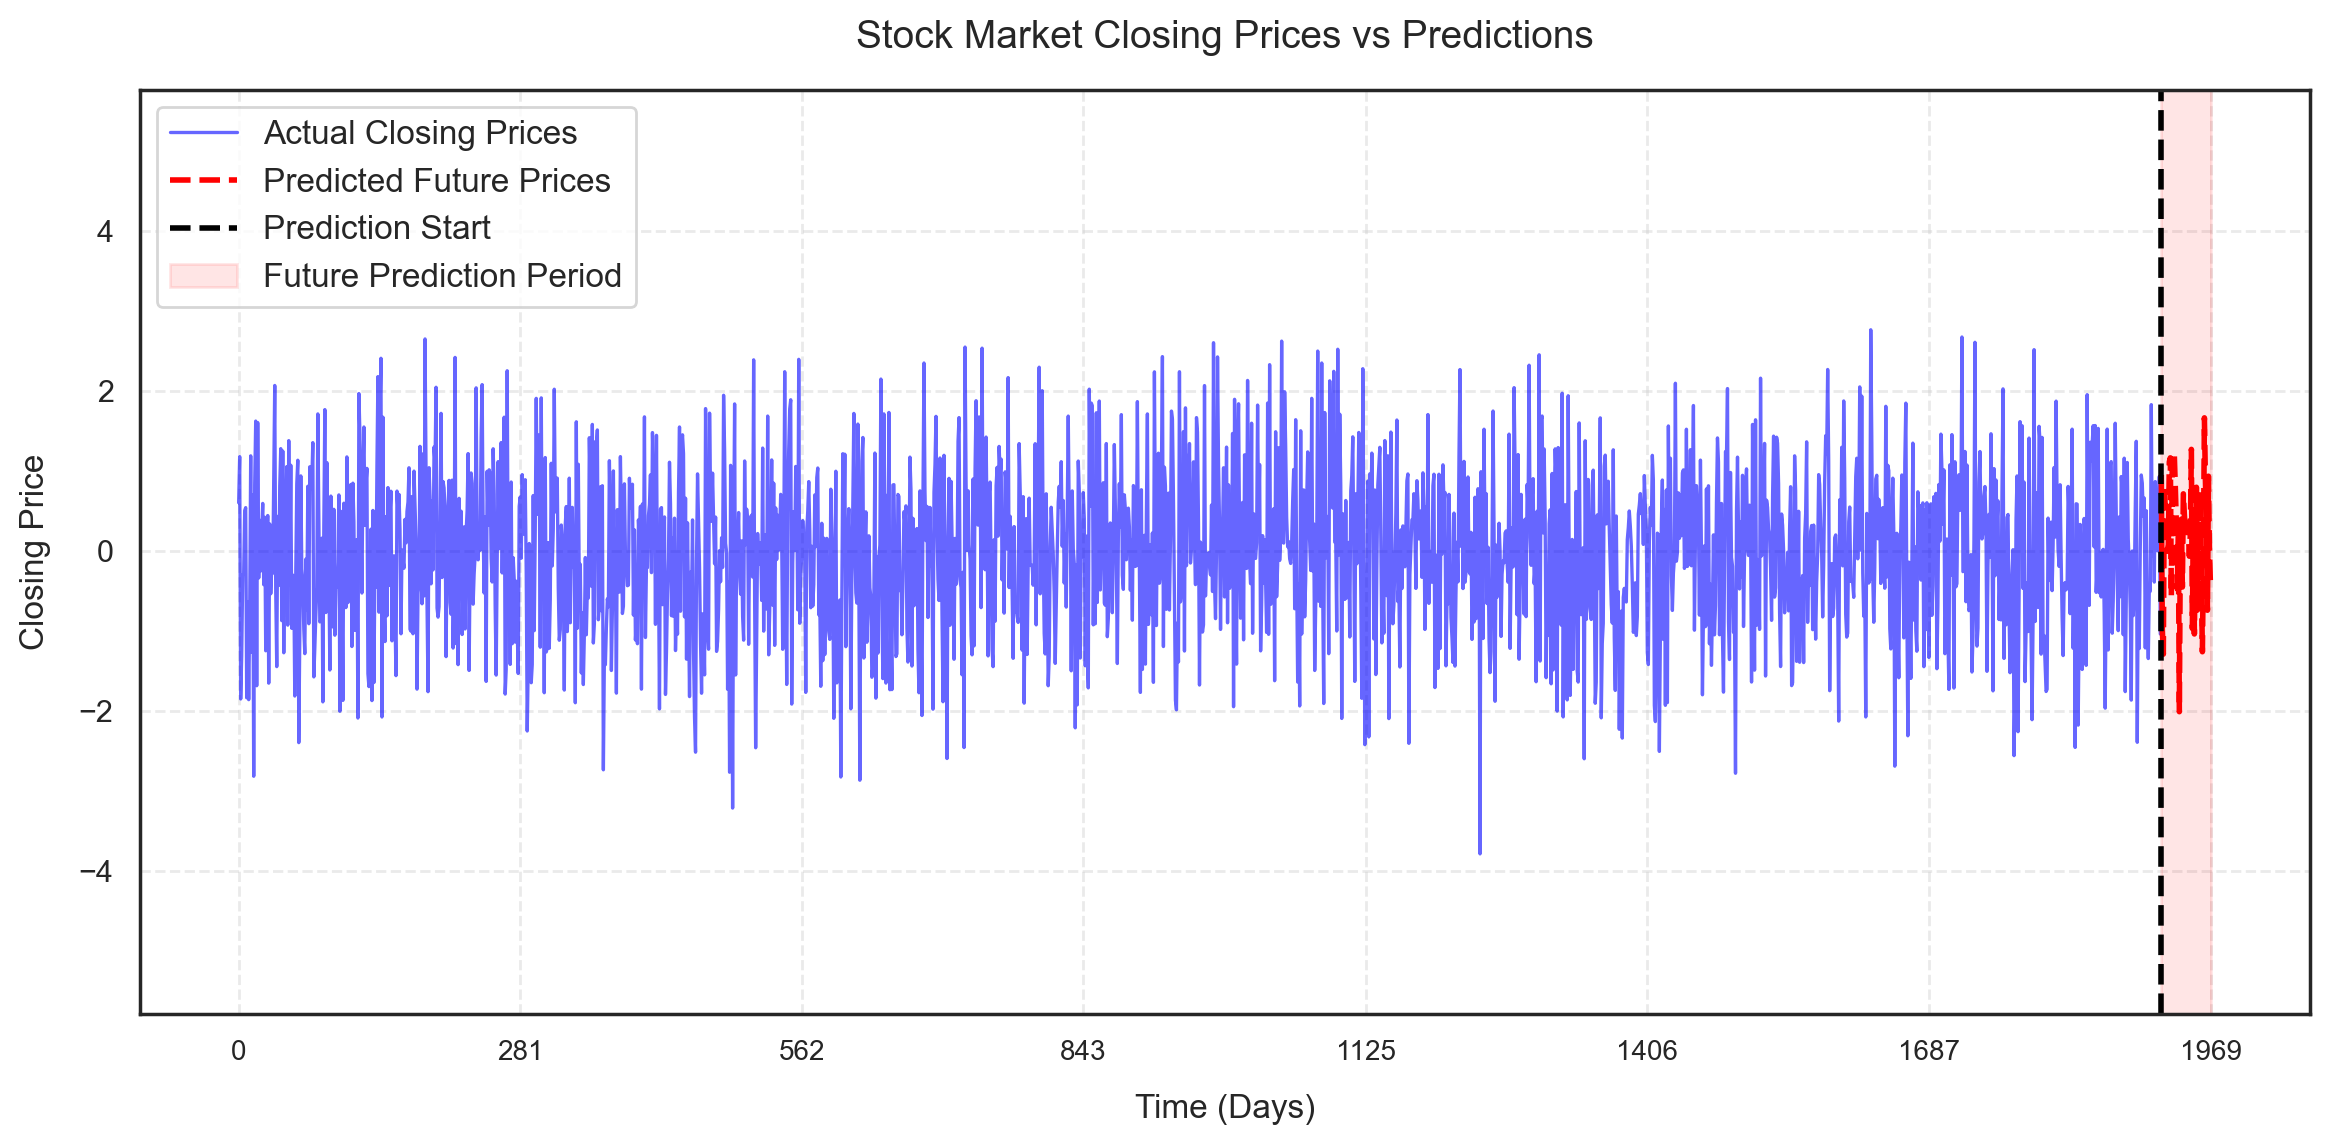

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated Data (Replace with your real data)
dates = np.arange(len(df)+future_days)  # Dates as index
actual_closing_prices = np.random.randn(len(df))  # Less noise in actual prices
predicted_prices = np.random.randn(future_days)  # Smoother predictions

# Create figure with better aspect ratio and higher DPI for clarity
plt.figure(figsize=(14, 6), dpi=200)
# Plot actual closing prices with reduced noise and opacity
plt.plot(dates[:len(df)], actual_closing_prices, label="Actual Closing Prices", 
         color='blue', linewidth=1.2, alpha=0.6)

# Plot predicted prices with a bolder dashed line
plt.plot(dates[len(df):], predicted_prices, label="Predicted Future Prices", 
         color='red', linestyle='dashed', linewidth=2)

# Vertical line to indicate forecast start
plt.axvline(x=len(df), color='black', linestyle='--', linewidth=2, label="Prediction Start")

# Shade the future prediction region
plt.axvspan(len(df), len(df)+future_days, color='red', alpha=0.1, label="Future Prediction Period")

# Adjust Y-axis limits for more price space
plt.ylim(min(actual_closing_prices) - 2, max(actual_closing_prices) + 3)

# Improve X-axis readability
plt.xticks(np.linspace(0, len(df)+future_days, num=8, dtype=int), fontsize=10)

# Labels, Title, and Legend with more spacing
plt.xlabel("Time (Days)", fontsize=12, labelpad=10)
plt.ylabel("Closing Price", fontsize=12, labelpad=10)
plt.title("Stock Market Closing Prices vs Predictions", fontsize=14, pad=15)
plt.legend(fontsize=12, loc="upper left")

# Grid adjustments for better clarity
plt.grid(True, linestyle='--', alpha=0.4)

# Show the improved plot
plt.show()

# for error calculation:

In [76]:
y_predicted=test_result_close[-20:]
print(y_predicted)

[378.4719  374.48807 371.04507 368.57037 366.97043 365.81537 364.84998
 364.33365 364.83792 366.35925 368.29004 370.01312 371.11798 371.3621
 370.82437 369.69095 368.21527 367.2644  368.1199  370.8642 ]


In [77]:
dferror=pd.DataFrame(df["Close"].tail(20))
# dferror.reset_index(inplace=True)
dferror.head()

,Close
Date,
2025-01-21,359.0
2025-01-22,369.8
2025-01-23,366.0
2025-01-26,356.5
2025-01-27,353.0


In [78]:
dferror["Predicted"]=y_predicted
dferror["Error"]=abs((dferror["Close"]-dferror["Predicted"])/dferror["Close"]*100)
dferror.tail(20)

,Close,Predicted,Error
Date,,,
2025-01-21,359.0,378.471893,5.423926
2025-01-22,369.8,374.488068,1.267731
2025-01-23,366.0,371.045074,1.378436
2025-01-26,356.5,368.570374,3.385799
2025-01-27,353.0,366.970428,3.957628
2025-01-28,357.0,365.815369,2.469291
2025-02-02,367.0,364.849976,0.585838
2025-02-03,372.0,364.333649,2.060847
2025-02-04,369.3,364.837921,1.208253


In [79]:
AvgError=np.mean(dferror["Error"])
AvgError

np.float64(1.9817255012187929)

In [80]:
dferror.to_csv("future_df.csv", index=False)